Cleaned up notebook that focuses on the important bits of my dwarf-spheroidal galaxy pipeline. Currently tuned in to the Sextans galaxy. Will make a tweaked version that's more generic. 

#### Part 1: Housekeeping
- Imports
- Define functions
#### Part 2: Get field data
- Input field, make plots of proper motion & RVs
- Make cuts to data based on PM & RV, plus cut on log G (log g<3 for giants)
#### Part 3: Summary plots/analysis of remaining stars
- Plot stars on their own, use galaxy data to make CMD.
- Aside: ASPCAP vs RV values
- V-error plots.
- Make fake stars

Once members are identified, we then move to Joker fitting. Do this on Tempest

#### Part 4: Post Joker analysis

- Derive and add things to data tables - do I want to make this into a function to just make it easier to pass different folders? Yeah that'd probably be best. 
- Do likelihood calculations, false-positive rejection. These are our candidate binaries.
- Do the binary fraction calculation.

#### Part 5: Data outputs

- Make many plots of different things.
- semi-amplitude plots?
- Galaxy-level Semi-amplitude plots (remake the surface one with just "good"stars)
- E vs P plot?
- Get plots from 
- Make website pages for things.
#### Misc things
- Star spectra plotter

# Part 1: Housekeeping

In [1]:
from astropy.io import fits  #Import libraries
from astropy.table import unique, Table
from astropy.io import ascii
from astropy.io.fits import writeto
from astropy.time import Time
import astropy.table as tab
import astropy.units as u
import astropy.constants as c

from glob import glob
from glob import iglob
import pathlib
import string
import os
import copy as cp

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from dlnpyutils.utils import *
from dlnpyutils import coords
import thejoker as tj
import twobody as tb

import sklearn
from sklearn import datasets, linear_model
from sklearn.cluster import DBSCAN
sklearn.set_config(enable_metadata_routing=True)

from matplotlib.offsetbox import AnchoredText

        Use @ instead. [dlnpyutils.coords]


In [2]:
all_star = Table.read('allStar-dr17-synspec_rev1.fits') #Star-level summary table
all_visits = Table.read('allVisit-dr17-synspec_rev1.fits') #Visit-level summary table

In [3]:
def get_data(sID):
    """
    Given a star's APOGEE ID, collect its RV data into a Joker RV data object. Remove nan and RV_REJECT points
    """
    visits = all_visits[all_visits['APOGEE_ID']==sID] #Visits with failed/bad RVs will be masked

    visit_mask = np.invert(visits["VHELIO"].mask) #Invert the mask, then use it to remove masked entries.
    vreject_mask = (visits["STARFLAG"] &(2**19)==0) #Remove RV_REJECT things
    
    mask = visit_mask & vreject_mask
    
    col1 = visits["JD"][mask]
    col2 = visits["VHELIO"][mask]
    col3 = visits["VRELERR"][mask]
    
    col2.unit = u.km/u.s #Make sure the units are correct.
    col3.unit = u.km/u.s
    
    data = tj.RVData(t=col1, rv = col2, rv_err = col3) #Make into a Joker RV object
    
    return data

In [4]:
def get_full_data(sID):
    """
    Given a star's APOGEE ID, collect its RV data into a Joker RV data object. Do not remove RV_REJECT points
    """
    visits = all_visits[all_visits['APOGEE_ID']==sID] #Visits with failed/bad RVs will be masked

    visit_mask = np.invert(visits["VHELIO"].mask) #Invert the mask, then use it to remove masked entries.
    
    col1 = visits["JD"][visit_mask]
    col2 = visits["VHELIO"][visit_mask]
    col3 = visits["VRELERR"][visit_mask]
    
    col2.unit = u.km/u.s #Make sure the units are correct.
    col3.unit = u.km/u.s
    
    data = tj.RVData(t=col1, rv = col2, rv_err = col3) #Make into a Joker RV object
    
    return data

In [5]:
def line_model(pars, x): #simple linear model
    """
    Evaluate a straight line model at the input x values.
    Assums y=mx + b format, with pars[0] = b, pars[1] = a
    """
    return pars[0] + pars[1]* np.array(x) #given a set of parameters, return the value of the line at x

In [6]:
def plt_lin_fit (a,b,data): #plot a simple line
    x1 = np.min(data.t.value) #Find the desired bounds
    x2 = np.max(data.t.value)

    y1 = a + x1*b #Find the value at those endpoints
    y2 = a + x2*b

    plt.axline((x1,y1),(x2,y2))

In [7]:
def lin_fit (data):  #fit a line to RV data using line_model
    x = (data.t.value)-data.t_ref.value #Dates are given in MJD, here instead we set t_0 = 0
    y = data.rv.value #The RV values
    y_err = data.rv_err.value
    X = np.vander(x, N=2, increasing=True) #Look up what this means from Adrian's notebook

    Cov = np.diag(y_err**2)
    Cinv = np.linalg.inv(Cov)

    # using the new Python matrix operator
    best_pars_linalg = np.linalg.inv(X.T @ Cinv @ X) @ (X.T @ Cinv @ y)

    # we can also get the parameter covariance matrix
    #pars_Cov = np.linalg.inv(X.T @ Cinv @ X)

    return (x,y,y_err,best_pars_linalg)

In [8]:
def ln_likelihood(x,y,y_err, pars): #Calculate log likelihood of a linear model
    N = len(y)
    dy = y - line_model(pars, x)
    ivar = 1 / y_err**2  # inverse-variance
    return -0.5 * (
        N * np.log(2 * np.pi)
        + np.sum(2 * np.log(y_err))
        + np.sum(dy**2 * ivar)
    )

In [9]:
def mass2(p,k,e,mstar=1.0): #Approximate the mass of a binary companion
    """
    Calculate secondary mass for Keplerian orbit
    p - period (If units not given, assumed to be in days.)
    k - semi-amplitude (If units not given, assumed to be in km/s.)
    e - eccentricity 
    mstar - primary star mass (if units not given, assumed to be in solar masses. Default 1Msol)
    """
    
    if not('time' in u.get_physical_type(p)):
        p = p *u.day
    if not('speed' in u.get_physical_type(k)):
        k = k *(u.km/u.s)
    if not ('mass' in u.get_physical_type(mstar)):
        mstar = m *u.solMass

    k = np.abs(k)
    G = c.G
    mass_fn = (p * k**3)*(1-e**2)**(3/2) / (2*np.pi*G)

    M_one = (mass_fn*(mstar)**2)**(1./3.)
    M_two = (mass_fn*(mstar+M_one)**2)**(1./3.)
    m_sini = (mass_fn*(mstar+M_two)**2)**(1./3.)

    #print(msini)
    return m_sini.to(u.solMass)

In [10]:
def period_at_surface(M1, logg, e=0, M2=0):  #calculate the approximate orbital period at the surface of a star
    G = c.G
    #If input masses have no mass units, assume it is given in solar masses.
    if not('mass' in u.get_physical_type(M1)):
        M1 = M1 *u.Msun
    if not('mass' in u.get_physical_type(M2)):
        M2 = M2 *u.Msun
    
    R1 = np.sqrt(G*M1 / (10**logg * u.cm/u.s**2))
    a = R1/(1-e)
    P = 2*np.pi * (a**(3/2))/np.sqrt(G*(M1+M2)) 
    return P.to(u.day)

In [11]:
def v_err_adj_1(v_err): #Crude v_err adjustment
    if ('velocity' in u.get_physical_type(v_err)):
        v_err = (v_err.to(u.km/u.s)).value

    offset = np.sqrt(((3.5*v_err)**1.2)**2 + 0.072**2)
    return offset

In [12]:
def v_err_adj_2(v_err): #More sophisticated v_err adjustment
    if ('velocity' in u.get_physical_type(v_err)):
        v_err = (v_err.to(u.km/u.s)).value
    
    m = 1.13893 #Averages for multiple runs of RANSAC
    b = 0.424407

    v_err_adjusted = 10**(m*np.log10(v_err)+b)
    return v_err_adjusted *(u.km/u.s)

In [13]:
def get_m_gal(): #Will replace with a gaussian generator later. For now, our mass range is pretty tight, so this is a good approximation.
    return 0.7939423076923077 *u.solMass

In [14]:
def rand_sini(): #Generate a theta such that the random angles are distributed evenly over a sphere.
    r2 = np.random.rand()
    sini = np.sqrt(1 - r2**2)
    #sign = 2 * np.random.randint(2) - 1 #whether to take the positive or negative square root
    return sini #*sign

In [15]:
def get_K(M1, M2, P, e=0, i=90): #Calculate expected semi-amplitude from a mass
    """
    Calculate the expected semi-amplitude of a given binary system, given the masses.
    M1 - mass of primary body (If units not given, assumed to be in solar mass.)
    M2 - mass of secondary body (If units not given, assumed to be in solar mass.)
    P - orbital period (If units not given, assumed to be in days)
    i - inclination (assumed to be in degrees)
    e - ecentricity, should be between 0 and 1
    """

    if not('mass' in u.get_physical_type(M1)):
        M1 = M1 *u.solMass
    if not('mass' in u.get_physical_type(M2)):
        M2 = M2 *u.solMass
    if not ('time' in u.get_physical_type(P)):
        P = P *u.day
    if not ('angle' in u.get_physical_type(i)):
        i = i * u.degree
        i = i.to(u.radian)
    
    qnt1 = (2*np.pi*c.G/P) / ((M2+M1)**2)
    K0 = qnt1**(1/3)* M2 * np.sin(i)
    K = K0 * (1-e**2)**(-1/2)
    return np.abs(K.to(u.km/u.s))

In [16]:
def get_mass2(P, K, e, M1=1.0, i=90): #Calculate companion mass from semi-amplitude
    """
    Calculate the expected companion mass of a system, given the semi-amplitude
    P - orbital period (If units not given, assumed to be in days)
    K - semi-amplitude of the primary body's RV (If units not given, assumed to be in km/s.)
    e - ecentricity, should be between 0 and 1
    M1 - mass of primary body (If units not given, assumed to be in solar mass.)
    i - inclination (assumed to be in degrees). Defaults to 90°, which will give the minimum companion mass.
    """

    if not('time' in u.get_physical_type(P)):
        P = P *u.day
    if not('speed' in u.get_physical_type(K)):
        K = K *(u.km/u.s)
    if not ('angle' in u.get_physical_type(i)):
        i = i * u.degree
        i = i.to(u.radian)
    if not ('mass' in u.get_physical_type(M1)):
        M1 = M1 *u.solMass

    K = np.abs(K)  #Get the magnitude of K, sign doesn't matter but leads to weird math
    G = c.G
    mass_fn = (P * K**3)*(1-e**2)**(3/2) / (2*np.pi*G)  #Calculate the mass function of the system

    a = (M1/mass_fn) * np.sin(i)**3  #Calculate the (only non-trivial) polynomial coefficient (function expressed in q, the mass ratio)
    a = a.decompose() #make sure units are simplified.

    delta_0 = 1 + 6*a #Use the general cubic formula to find the real root of q (in depressed form)
    delta_1 = -2 -18*a - 27* a**2
    part1 = np.sqrt(delta_1 **2 - 4*(delta_0)**3)
    C1 = np.cbrt((delta_1 +part1)/ 2)

    q = (-1/(3*a)) *(-1 + C1 + delta_0/C1) #Convert out of depressed form

    return (q*M1.to(u.solMass)) #Convert mass ratio back to companion mass

In [17]:
def calc_sim_likelihoods(data_folder, samples_folder):
    data_folder = "toy_data/"+data_folder
    samples_folder = "samples/"+field+"/"+samples_folder
    samples_files = sorted(glob(samples_folder+"*"))

    col1 = Table.Column(name="LINEAR_LN_LIKELIHOOD",length=len(samples_files))
    col2 = Table.Column(data=np.full((len(samples_files),256), np.nan), name="JOKER_LN_LIKELIHOOD")
    sim_LIKELIHOODs = Table((col1,col2))

    for file in samples_files:
        samples = tj.JokerSamples.read(file)

        foo_path = pathlib.Path(file)
        fID = foo_path.parts[-1].split(".")[0]
        ID = fID.split("_")[1]

        data_path = data_folder+"/rv_sim_"+ID+".fits"
        sim_data = Table.read(data_path)

        sim_data["VHELIO"].unit = u.km/u.s
        sim_data["VRELERR"].unit = u.km/u.s

        data = tj.RVData(t=sim_data["MJD"], rv = sim_data["VHELIO"], rv_err = sim_data["VRELERR"])

        sugar = samples.ln_unmarginalized_likelihood(data)
        frosting = np.append(sugar,np.full(256-len(sugar), np.nan))

        x,y,y_err,best_pars_linalg = lin_fit(data)
    
        cake = ln_likelihood(x,y,y_err,best_pars_linalg)

        (sim_LIKELIHOODs["LINEAR_LN_LIKELIHOOD"][int(ID)-1]) = cake
        (sim_LIKELIHOODs["JOKER_LN_LIKELIHOOD"][int(ID)-1]) = frosting

    return sim_LIKELIHOODs

In [18]:
def calc_real_likelihoods(samples_folder, reject_flag):
    path = "samples/"+field+"/"+samples_folder #change as necessary, think I need to regenerate data first. 
    sample_files = glob(path+"*")  
    
    col0 = apo_vpm["APOGEE_ID"]
    col1 = Table.Column(name="LINEAR_LN_LIKELIHOOD",length=len(sample_files))
    col2 = Table.Column(data=np.full((len(sample_files),256), np.nan), name="JOKER_LN_LIKELIHOOD")
    LIKELIHOODs = Table((col0,col1,col2))

    #for file in sample_files:
    #    file_path = pathlib.Path(file)
    #    sID = file_path.parts[-1].split("_")[0]
    for star in apo_vpm:
        sID = star["APOGEE_ID"]
        read_path = path+sID+"_samples.hdf5"
        
        samples = tj.JokerSamples.read(read_path)

        if reject_flag==True:
            data = get_data(sID)
        else:
            data = get_full_data(sID)

        x,y,y_err,best_pars_linalg = lin_fit(data)

        cake = ln_likelihood(x,y,y_err,best_pars_linalg)
        sugar = samples.ln_unmarginalized_likelihood(data) #Joker likelihoods
        frosting = np.append(sugar,np.full(256-len(sugar), np.nan))

        (LIKELIHOODs["LINEAR_LN_LIKELIHOOD"][LIKELIHOODs["APOGEE_ID"]==sID]) = cake
        (LIKELIHOODs["JOKER_LN_LIKELIHOOD"][LIKELIHOODs["APOGEE_ID"]==sID]) = frosting

    return LIKELIHOODs

In [19]:
def calc_sim_percentile( data_folder, samples_folder, percentile=99):
    likelihoods = calc_sim_likelihoods(data_folder, samples_folder)

    #Step 1: Array of all mean simulated ∆LL 
    sim_delta_ll = likelihoods["JOKER_LN_LIKELIHOOD"]-likelihoods["LINEAR_LN_LIKELIHOOD"][:,None]
    sim_mean_delta_ll = np.nanmean(sim_delta_ll,axis=1)
    #Step 2: Compute percentile value
    sim_percentile = np.nanpercentile(sim_mean_delta_ll,percentile)

    return sim_percentile

In [20]:
def calc_real_percentile( samples_folder, reject_flag=False, percentile = 5):
    likelihoods = calc_real_likelihoods(samples_folder, reject_flag)

    apo_delta_ll = likelihoods["JOKER_LN_LIKELIHOOD"]-likelihoods["LINEAR_LN_LIKELIHOOD"][:,None]
    apo_percentile = np.nanpercentile(apo_delta_ll,percentile,axis=1)
    return apo_percentile

# Part 2: Galaxy Level Info

Now we need to identify our target in the APOGEE files, and isolate the member stars. First, find the field (or fields, you might have to tweak that if it's spread over multiple) in the list of APOGEE targets. Then, look up the most recent mean RV and proper motion values for the galaxy as can be found in the literature. Enter those values below. 

In [21]:
#Un-comment to print out all fields in DR17
#with np.printoptions(threshold=np.inf):
#    print(np.unique(all_star["FIELD"].data))

In [22]:
field = 'SEXTANS' #Field name
rv = 224.3       #Average radial velocity of the target (km/s)
pm_ra = -0.409   #Proper motion of the target
pm_dec = -0.047  ##mas/year

In [23]:
im_folder = "images/"+field #Make a place to output all images

if not os.path.exists(im_folder):
    os.makedirs(im_folder)

In [24]:
apo_gal = all_star[all_star["FIELD"]==field] #Check number of stars in field
len(apo_gal)

265

Now, let's look at what we have. How often were these stars visited, and what range of sizes (gravities) do they tend to have? Most targets outside of the Milky Way should be red giants with log g <3, anything higher will probably be a field star. 

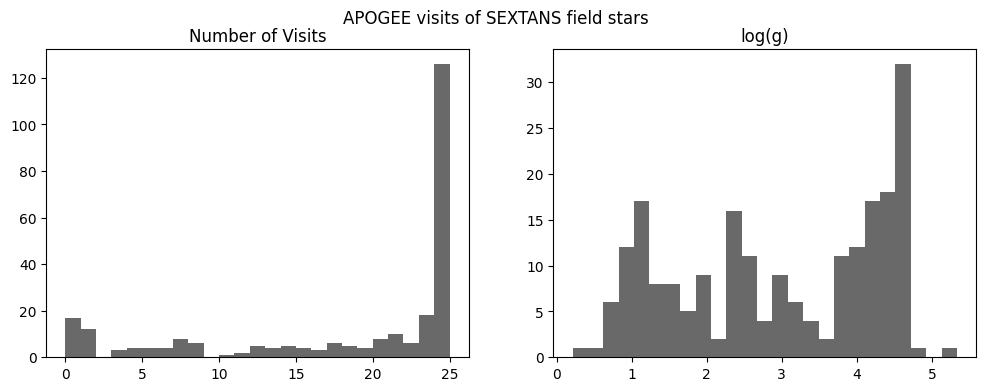

In [25]:
fig, (ax1,ax2) = plt.subplots(1, 2)

fig.set_size_inches([12,4])
fig.suptitle("APOGEE visits of " +field+" field stars")

ax1.set_title("Number of Visits") #Get number of visits. I want to refine this using nan visits and RV reject
ax1.hist(apo_gal["NVISITS"],bins=25,color='dimgray');

ax2.set_title("log(g)") #See what kind of stars we have. Some of them appear to be dwarfs.
ax2.hist(apo_gal["LOGG"],bins=25,color='dimgray');

plt.savefig(im_folder + "/sextans_field_visits.png",dpi=150,bbox_inches='tight') 

## Plots to look at field kinematics

For a dwarf-spheroidal galaxy, the kinematic clustering should be pretty tight and readily visible in both RV and proper motion:

Text(0, 0.5, '')

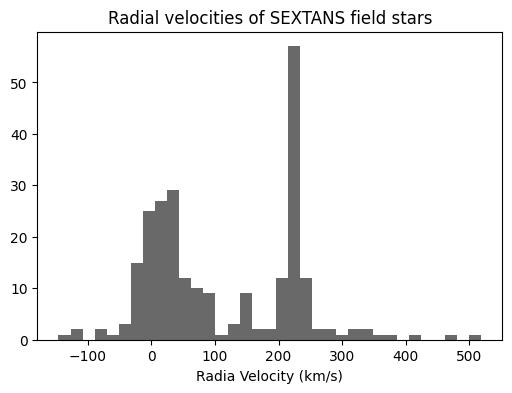

In [26]:
plt.figure(figsize=(6,4))
counts6, bins3,patches=plt.hist(apo_gal["VHELIO_AVG"],bins=35,color='dimgray')

plt.title("Radial velocities of "+ field+" field stars")
plt.xlabel("Radia Velocity (km/s)")
plt.ylabel("")

Text(0.5, 1.0, 'Gaia Proper motion for SEXTANS observations')

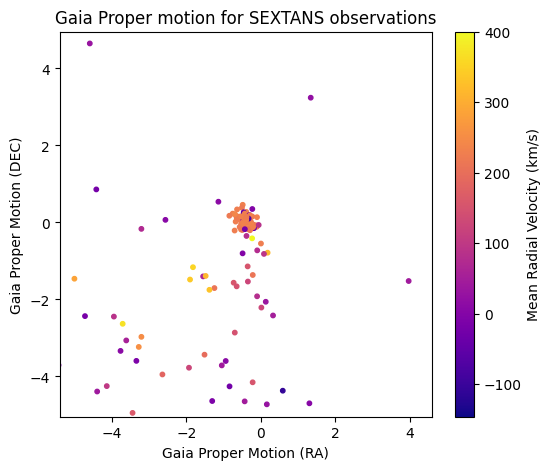

In [27]:
ra_min = pm_ra-5  #mas/year
ra_max = pm_ra+5  #Adjust as needed depending on target
dec_min = pm_dec-5
dec_max = pm_dec+5

pm_fig = plt.figure(figsize=(6,5))
plt.scatter(apo_gal["GAIAEDR3_PMRA"],apo_gal["GAIAEDR3_PMDEC"],c=apo_gal["VHELIO_AVG"],s=10,cmap="plasma",vmax = 400)
plt.xlim([ra_min,ra_max])
plt.ylim([dec_min,dec_max])
plt.colorbar(label='Mean Radial Velocity (km/s)')

plt.xlabel('Gaia Proper Motion (RA)')
plt.ylabel('Gaia Proper Motion (DEC)')
plt.title('Gaia Proper motion for '+ field+" observations")

#plt.savefig(im_folder +"sextans_field_pms.png",dpi=200,bbox_inches='tight') #For visualization purposes only. Use 2nd version of plot below

## Make cuts in RV & PM (& log G) to isolate galaxy members

Now we can start isolating the stars using the kinematics. For Sextans, I got the rv scatter from literature, if that's not available, just estimate something from the RV graph and divide by 3. For proper motion, I kinda eye-balled it as well. 

In [28]:
rv_scatter = 7.9  #Spread of the target's radial velocity (default is to select stars within 3x this range)
pm_radius = 0.5   #Radius in the proper motion plane (uses simple distance from center)


In [29]:
rv_min = rv - (3*rv_scatter)  #Get ~3 standard deviations on either side of the galaxy's known rv scatter
rv_max = rv + (3*rv_scatter)

vcut_mask = (apo_gal["VHELIO_AVG"]>rv_min)&(apo_gal["VHELIO_AVG"]<rv_max)

In [30]:
pm_delta = np.sqrt( (apo_gal["GAIAEDR3_PMRA"]-pm_ra)**2 + (apo_gal["GAIAEDR3_PMDEC"]-pm_dec)**2)
pm_mask = pm_delta < pm_radius #Calculate 'distance' in proper motion space.
pm_mask = pm_mask.data

Also, as mentioned above, giant stars have log(g) < 3, so anything with a higher log(g) will likely be a field star.

In [31]:
logg_mask = (apo_gal["LOGG"]<3)| (apo_gal["LOGG"]<3).mask #Might not be needed for non dwarf-galaxy targets

In [32]:
apo_vpm = apo_gal[vcut_mask & pm_mask] #Make two lists of stars, for posterity. Rest of the notebook includes non-giant stars
apo_vpmg = apo_gal[vcut_mask & pm_mask & logg_mask]

In [33]:
apo_vpm.sort("LOGG") #Sort them by log(g), if nothing else to make sure there's a consistent ordering to them. 
apo_vpmg.sort("LOGG")
print(len(apo_vpmg)) 

66


### Re-make RV/PM plots with selection overlain

These are the ideal science plots, use them for papers

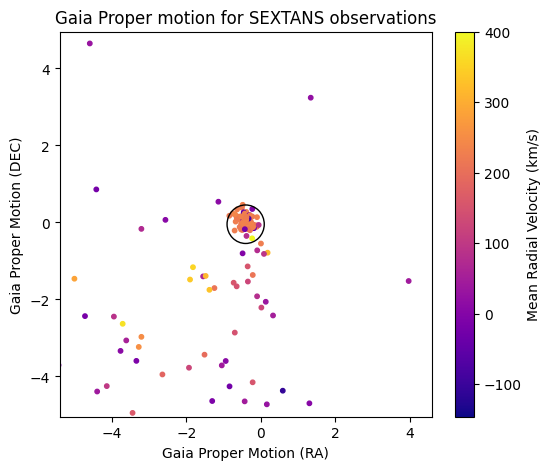

In [34]:
pm_circ = plt.Circle((pm_ra,pm_dec),pm_radius,color='black',fill=False) #make a circle showing our proper motion range
ax = pm_fig.gca()
ax.add_patch(pm_circ)

pm_fig.savefig(im_folder + "/sextans_field_pms.png",dpi=200,bbox_inches='tight')
pm_fig

[-115.4  -99.6  -83.8  -68.   -52.2  -36.4  -20.6   -4.8   11.    26.8
   42.6   58.4   74.2   90.   105.8  121.6  137.4  153.2  169.   184.8
  200.6  216.4  232.2  248.   263.8  279.6  295.4  311.2  327.   342.8
  358.6  374.4  390.2  406.   421.8]


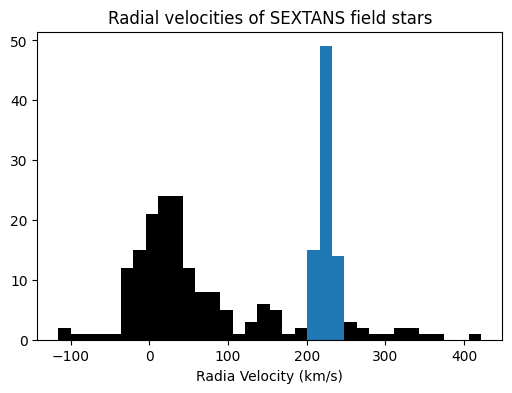

In [35]:
nbins = 35  #Code to make sure our rv bins overlap cleanly with our selection in the histogram. Enter total number of bins here.
binz = np.zeros(nbins)

place = 20  #Where you want the selection to be placed horizontally
width = 3   #How wide you want the selection to be.
bin_delta = (rv_max-rv_min)/width  #From these parameters, calculate how wide each bin should be. 

for i in range(nbins):
    binz[i] = rv_min - (place-i)*bin_delta  #From all this, calculate the cut-offs for the bins. 

print(binz)

apo_v = apo_gal[vcut_mask]  #Finally, plot the RV histogram, with the selected stars overlain.

plt.figure(figsize=(6,4))
counts6, bins3,patches=plt.hist(apo_gal["VHELIO_AVG"],bins=binz,color='black')
plt.hist(apo_v["VHELIO_AVG"],bins=binz,color='tab:blue')

plt.title("Radial velocities of "+ field+" field stars")
plt.xlabel("Radia Velocity (km/s)")
plt.ylabel("")

plt.savefig(im_folder + "/sextans_field_rvs.png",dpi=200,bbox_inches='tight')

## Summary Plots of members

This first cells are an attempt to figure out hwo many visits for different stars were actually successful. Might fiddle with this more.

Also includes a calculation of the baseline of observations

In [36]:
nominal_visits = np.empty(0)

for star in apo_vpmg:  #Calculate number of non-nan RVs, I think?
    sID = star["APOGEE_ID"]
    data = get_data(sID)
    n_visits = len(data)
    nominal_visits = np.append(nominal_visits,n_visits)

nominal_visits

array([23., 24., 23., 24., 23., 24., 24., 24., 23., 24., 18., 23., 20.,
       16., 24., 22., 23., 24., 19., 19., 23.,  8., 24., 23., 22., 12.,
       13., 24., 22., 13., 21., 24., 14., 22., 24., 23., 16., 23., 17.,
        6., 23., 23., 20., 18., 23.,  8., 14., 20., 12.,  8., 21., 14.,
       11., 17., 15., 21., 17., 11.,  4., 14.,  3., 23., 17., 24., 21.,
        8.])

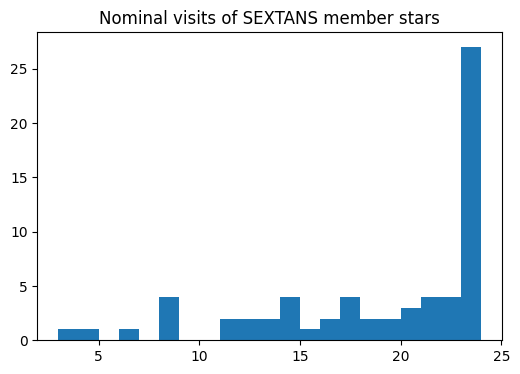

In [37]:
plt.figure(figsize=(6,4)) #Mean metalicity of the member stars.
plt.title("Nominal visits of "+ field+" member stars")

plt.hist(nominal_visits,bins=21)

plt.savefig(im_folder + "/sextans_nominal_visits.png",dpi=150,bbox_inches='tight')

(array([ 1.,  0.,  0.,  0.,  7.,  6.,  0.,  0.,  0., 52.]),
 array([707.04642 , 707.745506, 708.444592, 709.143678, 709.842764,
        710.54185 , 711.240936, 711.940022, 712.639108, 713.338194,
        714.03728 ]),
 <BarContainer object of 10 artists>)

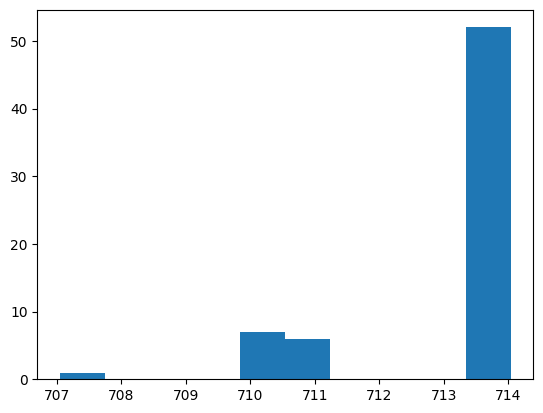

In [38]:
baselines = np.empty(0)

for star in apo_vpmg:  #Calculate number of non-nan RVs, I think?
    sID = star["APOGEE_ID"]
    data = get_data(sID)
    baselines = np.append(baselines, (max(data.t) -min(data.t)).value)

plt.hist(baselines)

### Some stats on the APOGEE visits

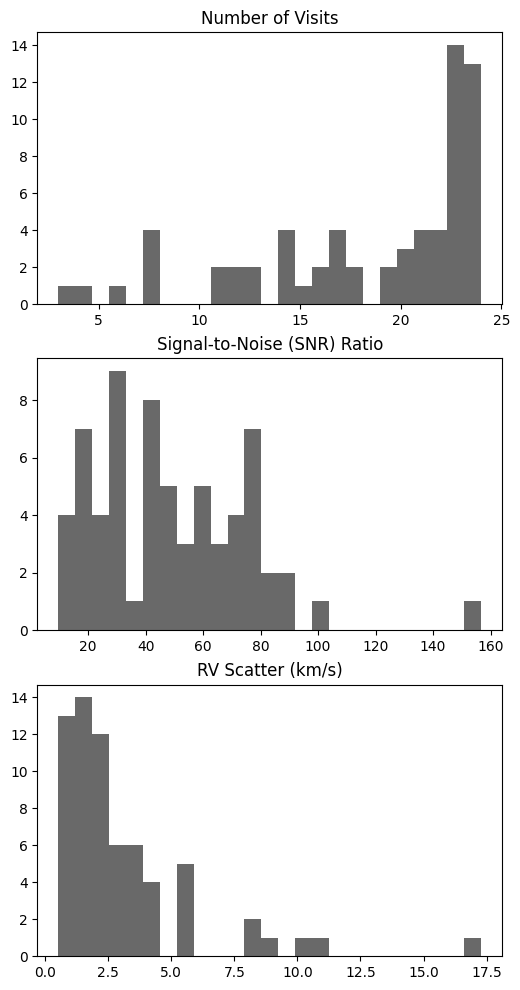

In [39]:
fig, ((ax1,ax2,ax3)) = plt.subplots(3, 1)
fig.set_size_inches([6,12])
#fig.suptitle("Summary of APOGEE Visits of "+ field+" Members")

ax1.set_title("Number of Visits")
ax1.hist(nominal_visits,bins=25,color='dimgray',label = "All-Visit visits") #tweak axes ranges to not be fractional

#n,bins,patches =ax1.hist(apo_vpm["NVISITS"],bins=25,color='dimgray',label="All-Star visits")
#ax1.hist(nominal_visits,bins=bins,color='tab:blue',hatch='//',alpha=0.4,label = "All-Visit visits")
#ax1.legend()
#ax1.set_xlabel("visits")
#ax1.set_ylabel("# of stars")

ax2.set_title("Signal-to-Noise (SNR) Ratio")
ax2.hist(apo_vpmg["SNR"],bins=25,color='dimgray')

ax3.set_title("RV Scatter (km/s)")
ax3.hist(apo_vpmg["VSCATTER"],bins=25,color='dimgray')

plt.savefig(im_folder + "/sextans_visit_stats.png",dpi=200,bbox_inches='tight')
#fig.savefig("sextans_visit_stats.png",dpi=200,bbox_inches='tight')

-1.8023207982381184


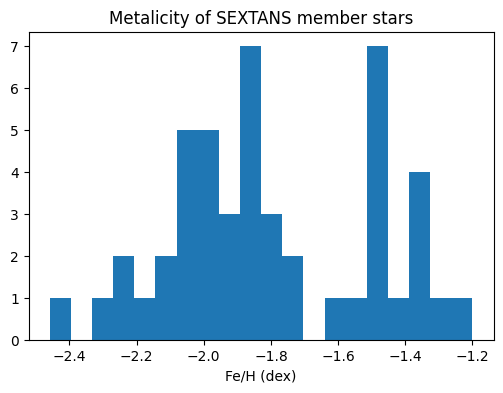

In [40]:
plt.figure(figsize=(6,4)) #Mean metalicity of the member stars.
plt.title("Metalicity of "+ field+" member stars")

plt.hist(apo_vpmg["FE_H"],bins=20);
plt.xlabel("Fe/H (dex)")
print(np.ma.mean(apo_vpmg["FE_H"]))

### Color-Magnitude Diagram

Before running this cell, you need to collect an isochrone grid file from https://stev.oapd.inaf.it/cgi-bin/cmd

I took age and metallicity values from the literature. 

In [41]:
iso_grid = ascii.read("misc/"+field+"_isochrone.dat") #Load in the isochrone grid file
isochrone_ind = np.where((iso_grid["logAge"]==10.0) &(iso_grid["MH"]==-1.6)) #Target galaxy/cluster's parameters

isochrone = iso_grid[isochrone_ind]

mu = 19.8 #Target's distance modulus

<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
/var/folders/b5/gm7vz31d7cz5k6m1r9bknccr0000gp/T/ipykernel_23549/2088643470.py:4: SyntaxWarning: invalid escape sequence '\o'
  cbar = plt.colorbar(cmap="plasma",label="Mass (M$_\odot$)")


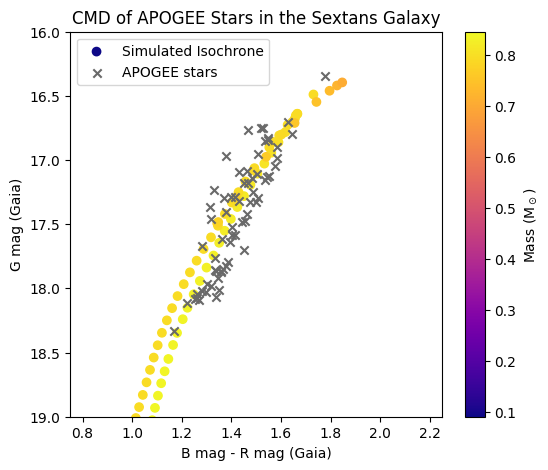

In [42]:
plt.figure(figsize=[6,5])
plt.scatter(isochrone["G_BPmag"]-isochrone["G_RPmag"],isochrone["Gmag"]+mu,c=isochrone["Mass"],
            label = "Simulated Isochrone",cmap ="plasma")
cbar = plt.colorbar(cmap="plasma",label="Mass (M$_\odot$)")
plt.scatter(apo_vpmg["GAIAEDR3_PHOT_BP_MEAN_MAG"]-apo_vpmg["GAIAEDR3_PHOT_RP_MEAN_MAG"],
            apo_vpmg["GAIAEDR3_PHOT_G_MEAN_MAG"],color='dimgray',marker="x", label="APOGEE stars")
plt.clim(min(isochrone["Mass"]), max(isochrone["Mass"]))
plt.xlabel("B mag - R mag (Gaia)")
plt.ylabel("G mag (Gaia)")
plt.title("CMD of APOGEE Stars in the Sextans Galaxy")
plt.legend()

#plt.hlines(18.3, 1,2)
plt.xlim(0.75,2.25) #Adjust as needed
plt.ylim(16,19)
ax = plt.gca()
ax.invert_yaxis()

plt.savefig(im_folder + "/sextans_CMD.png",dpi=200,bbox_inches='tight')

In [43]:
m_gal = np.mean(isochrone[isochrone["Gmag"] < -1.5]["Mass"]) #Average mass of the stars that overlap with the galaxy stars
sd_gal = np.std(isochrone[isochrone["Gmag"] < -1.5]["Mass"])
print(m_gal)
print(sd_gal)

0.7939423076923077
0.026317158384669623


### Log G vs temp

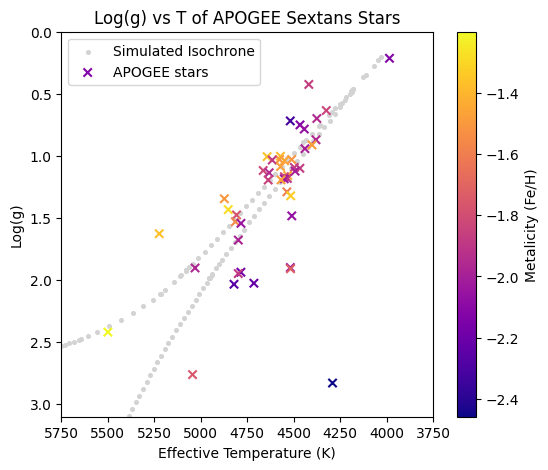

In [44]:
plt.figure(figsize=[6,5])
plt.scatter(10**isochrone["logTe"],isochrone["logg"],c='lightgray', s=7,   #isochrone["Mass"],
            label = "Simulated Isochrone")
plt.scatter(apo_vpmg["TEFF"],apo_vpmg["LOGG"],c=apo_vpmg["FE_H"],marker="x", label="APOGEE stars",cmap ="plasma")
cbar = plt.colorbar(label="Metalicity (Fe/H)")
plt.ylabel("Log(g)")
plt.xlabel("Effective Temperature (K)")
plt.title("Log(g) vs T of APOGEE Sextans Stars")
plt.legend()

#plt.hlines(18.3, 1,2)
#plt.xlim(0.75,2.25)
plt.xlim(3750,5750)
plt.ylim(0,3.1)
ax = plt.gca()
ax.invert_xaxis()
ax.invert_yaxis()

plt.savefig(im_folder + "/sextans_logg_teff.png",dpi=200)

# Part 3: Data Prep & Analysis

## Gaia data

First, let's grab some Gaia things. You'll need to find a sub-file for Gaia for the specific field you're looking at, or otherwise tweak this code depending on your data source.

In [45]:
gaia = Table.read("sextans_gaiadr3.fits")

gaia_inds = np.empty(0)

for ap_id in apo_vpm["GAIAEDR3_SOURCE_ID"]: #Cross match our sub-sample with the Gaia table, get index positions.
    gaia_pos =  int((np.where(gaia["source_id" ]==ap_id)[0][0]))
    gaia_inds = np.append(gaia_inds,gaia_pos)

print(len(gaia_inds))

gaia_sub =gaia[gaia_inds.astype(int)]

70


## V error adjustments

Here, we use RANSAC fitting to derive an adjustment to rv errors. This is based on divergences between v_err and v_scatter which (with the exceptions of binaries and other outliers) should form a 1:1 line. This adjustment was calibrated based on the properties of the Sextans targets, it should work for other dim dwarf-spheroidal galaxies. Nonetheless, double-check thiese plots to make sure they all look like a reasonable match for the errors of the galaxy we're looking at.  

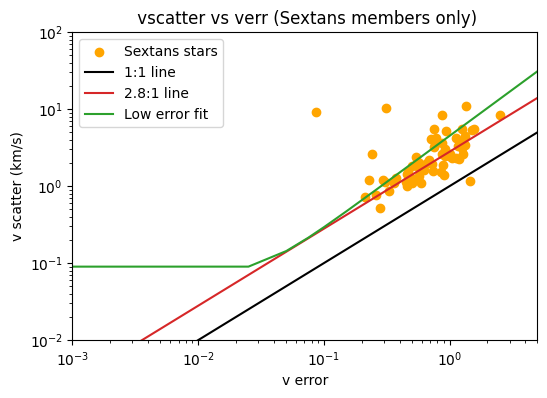

In [46]:
plt.figure(figsize=(6,4))
plt.title(" vscatter vs verr (Sextans members only)")
plt.xlabel("v error")
plt.ylabel("v scatter (km/s)")

plt.scatter(apo_vpmg["VERR"],apo_vpmg["VSCATTER"],color="orange", label="Sextans stars")

x = np.linspace(0,5,num=200)
plt.plot(x,x,color='black', label="1:1 line") #How v scatter and v error *should* correlate

plt.plot(x,x*2.8,color='tab:red', label="2.8:1 line") #A quick napkin math eyeball fit to the actual v-scatter in the Sextans member range.

fit_line = v_err_adj_1(x) #David's original v error adjustment function, works well for lower error (brighter) stars, but not these.

plt.plot(x,fit_line,color='tab:green',label="Low error fit")

plt.xlim(0.001,5)
plt.ylim(0.01,100)

plt.yscale('log')
plt.xscale('log')
plt.legend()

Text(0.5, 0, 'Temperature (Kelvin)')

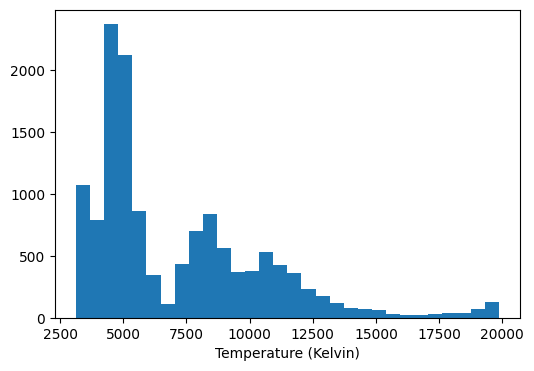

In [47]:
err_stars = all_star[((all_star["VERR"]>0.2)&(all_star["NVISITS"]>5))] #Get stars with large errors and lots of visits

plt.figure(figsize=(6,4))
plt.hist(err_stars["TEFF"],bins=30)#Given these errors/visits, how many stars do we have in this temperature range?
plt.xlabel("Temperature (Kelvin)")

In [48]:
err_stars_T = err_stars[(err_stars["TEFF"]<5500)]
err_stars_T = err_stars_T[(err_stars_T["FE_H"]< -1.4)] #Finally, make a metalicity cut based on the metalicity plot up in part 2
print(len(err_stars_T))

1656


In [49]:
fit_params = np.empty((1,2),dtype=float)

X = np.log10(err_stars_T["VERR"].reshape(-1,1)) #Since v scatter seems to be log-linear in v-error, let's cast the params to log scaling.
y = np.log10(err_stars_T["VSCATTER"])

for i in range(1000): #Now let's fit the v scatter multiple times to get a statistically robust "best" fit.
    ransac = linear_model.RANSACRegressor(residual_threshold=0.30) #Because of the presence of binaries, it's not immediately clear which 
    #RV values are "good" ones. RANSAC uses stastical methods to determine inliers and outliers, but doesn't always give the same results.
    ransac.fit(X, y) #Figure out the "inliers" and "outliers" of our v-error

    line_X = np.arange(X.min(), X.max())[:, np.newaxis]
    line_y_ransac = ransac.predict(line_X.reshape(-1,1)) #Generate a line over our range of v error

    m = ransac.estimator_.coef_[0] #Get coefficients
    b = ransac.estimator_.intercept_

    fit_params = np.append(fit_params, [[m,b]],axis=0) #Record them for later use
    #binned_dat = np.append(binned_dat, [[bin_t,bin_rv,bin_verr]],axis=0)

fit_params = fit_params[1:] #Some data-reshaping things, I forget *why* exactly we need these, but we do need them to make life easy.
fit_params = fit_params.T

In [50]:
print(np.std(fit_params[0])) #Average of our fit slope
print(np.median(fit_params[0]))

0.1733812814720165
1.1357955932617188


In [51]:
print(np.std(fit_params[1]))  #Average of our fit intersection
print(np.median(fit_params[1]))

0.07812701912427938
0.42433808743953705


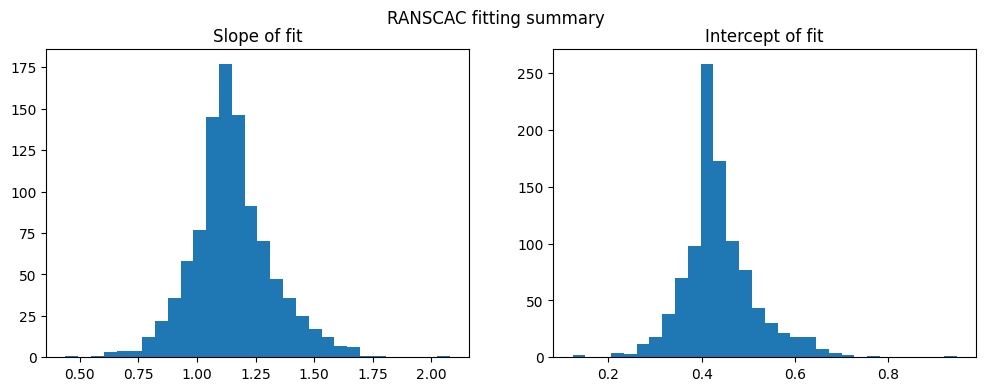

In [52]:
fig, (ax1,ax2) = plt.subplots(1, 2)

fig.set_size_inches([12,4])
fig.suptitle("RANSCAC fitting summary")

ax1.set_title("Slope of fit")
ax1.hist(fit_params[0],bins=30);

ax2.set_title("Intercept of fit")
ax2.hist(fit_params[1],bins=30);

Note that while we *can* pull fit values from the above things, and they will be quite close to the ones we used, I'm coding them in manually here for reproducability.

In [53]:
m = 1.13893 #Hard-coded these in for consistency, but they should match the outputs above the graph to at least two sig-figs. 
b = 0.424407

This cell is just to reproduce an inlier mask for plotting purposes. 

In [54]:
for i in range(1000): #Find a model that's really close to our stastical average one, to use for plotting purposes.
    ransac = linear_model.RANSACRegressor(residual_threshold=0.30)

    ransac.fit(X, y)

    delta_m = np.abs(ransac.estimator_.coef_[0] - m)
    delta_b = np.abs(ransac.estimator_.intercept_ - b)
    j = 0
    if ((delta_m<0.3)&(delta_b<0.15)):
        inlier_mask = ransac.inlier_mask_
        j+=1

print(j)

1


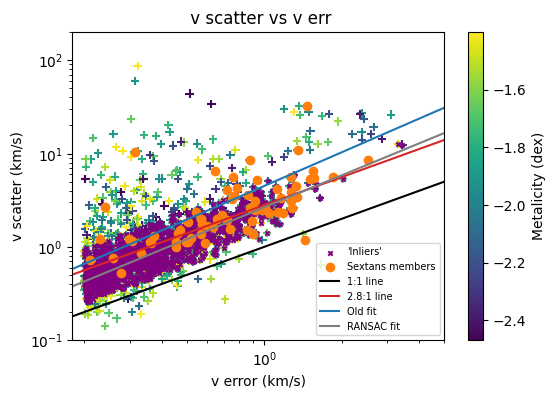

In [55]:
plt.figure(figsize=[6,4]) #plt.figure(figsize=[6,5])
plt.title(" v scatter vs v err")
plt.xlabel("v error (km/s)")
plt.ylabel("v scatter (km/s)")

plt.scatter(err_stars_T["VERR"],err_stars_T["VSCATTER"],marker='+',c=err_stars_T["FE_H"])
plt.colorbar(label="Metalicity (dex)")
plt.scatter(err_stars_T["VERR"][inlier_mask],err_stars_T["VSCATTER"][inlier_mask],marker='x',color="purple",s=10, label="'Inliers'")
#plt.scatter(err_stars_T["VERR"][outlier_mask],err_stars_T["VSCATTER"][outlier_mask],marker='+',,label="Outliers")
plt.scatter(apo_vpm["VERR"],apo_vpm["VSCATTER"], marker = 'o', color="tab:orange",label = 'Sextans members')

x = np.linspace(0.1,5,num=500)
plt.plot(x,x,color='black',label = "1:1 line")

plt.plot(x,x*2.8,color='tab:red',label = "2.8:1 line")

fit_line = v_err_adj_1(x)

plt.plot(x,fit_line,color='tab:blue',label = "Old fit")

adjusted_y = v_err_adj_2(x)

#plt.plot(10**line_X, 10**line_y_ransac, color = 'tab:gray',label = "RANSAC fit")
plt.plot(x, adjusted_y, color = 'tab:gray',label = "RANSAC fit")

plt.xlim(0.18,5)
plt.ylim(0.1,200)

plt.yscale('log')
plt.xscale('log')
plt.legend(prop={'size': 7})

plt.savefig(im_folder + "/scatter_vs_err.png",dpi=200,bbox_inches='tight')

After you've run this fitting a few times, go back up to the v_err_adjust2 function and change it as needed. 

## RV_REJECT things

In [56]:
reject_counts = []
nan_counts = []
good_visits = []

for star in apo_vpm:
    sID = star["APOGEE_ID"]

    visits = all_visits[all_visits['APOGEE_ID']==sID] #Visits with failed/bad RVs will be masked

    visit_mask = np.invert(visits["VHELIO"].mask) #Invert the mask, then use it to remove masked entries.
    vreject_mask = (visits["STARFLAG"] &(2**19)==0) #Remove RV_REJECT things

    reject_counts = np.append(reject_counts, sum(~vreject_mask))
    nan_counts = np.append(nan_counts, sum(~visit_mask))
    good_visits = np.append(good_visits, sum(visit_mask&vreject_mask))


(0.0, 25.0)

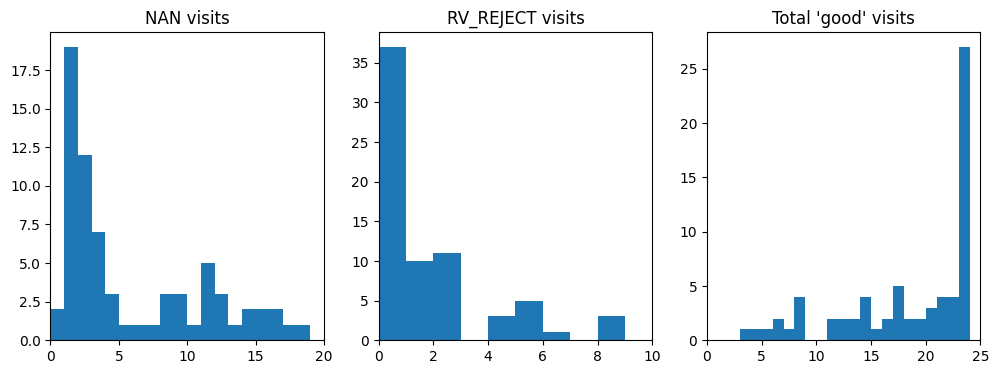

In [57]:
fig, (ax1,ax2,ax3) = plt.subplots(1, 3)

fig.set_size_inches([12,4])

ax1.set_title("NAN visits")
ax1.hist(nan_counts,bins=range(20));
ax1.set_xlim(0,20)

ax2.set_title("RV_REJECT visits")
ax2.hist(reject_counts,bins=range(10));
ax2.set_xlim(0,10)

ax3.set_title("Total 'good' visits")
ax3.hist(good_visits,bins=range(25));
ax3.set_xlim(0,25)

In [58]:
np.sum(reject_counts>0)

33

## Fake Star Simulation

Here we simulate fake stars with the same cadence as those observed in our target galaxy. The RVs are randomly generated based on the galactic average values, and the RV errors are taken from the ovservations and assigned at random. 

### Without Signal

First, let's generate some stars with (nominally) constant RVs. We introduce a bit of RV jitter to simulate measurement errors

In [59]:
def get_fake_rvs(mjd,err,signal=False):
    v_err = v_err_adj_2(err)
    toy_data = Table((mjd,v_err),names = ("MJD", "VRELERR"))  #Reuse errors and cadence of reals stars, generate fresh RVs
    toy_data.add_column(col = np.zeros(len(toy_data)),name="VHELIO")

    mean_v = rng.normal(rv,rv_scatter)  #Generate a random average velocity for this star, according to galaxy average
    carmel = rng.normal(mean_v, v_err) * (u.km/u.s)  #Generate some jitter about said average

    orchid = fits.Header() #Make a header tracking our "true" orbital parameters
    orchid["meanv"] = mean_v

    if(signal):
        p_flag=True
        while(p_flag):
            P = 10**(rng.normal(5.03, 2.28)) * u.day #Generate a period according to Raghavan, then select according to desired range.
            if(P.value>12):# and P.value<1422): 
                p_flag = False

        m1 = get_m_gal()
        m2 = (m1-(13*u.M_jupiter).to(u.solMass)) * np.random.rand() + (13*u.M_jupiter).to(u.solMass)

        e = np.random.rand()                                                                         
        i = np.arcsin(rand_sini()) * u.radian  #Get random inclination
        omega = 360 *np.random.rand() * u.degree #longitude of ascending nodes
        M0 = 360 *np.random.rand() * u.degree  #Random phase

        elements = tb.TwoBodyKeplerElements(P=P, m1 = m1, m2 = m2, e = e, i = i, omega = omega, M0 = M0 )  
        orb1 = tb.KeplerOrbit(elements.get_body(1))   #Make an orbitial model based on our random params
        fake_rvs = orb1.radial_velocity(Time(visits["MJD"],format='mjd')) #Print out a set of RVs with real star's cadence

        carmel +=fake_rvs 

        orchid["P"] = (P.value, P.unit)
        orchid["m1"] = (m1.value, m1.unit)
        orchid["m2"] = (m2.value, m2.unit)
        orchid["e"] = e
        orchid["i"] = (i.value, i.unit)
        orchid["omega"] = (omega.value, omega.unit)
        orchid["phase"] = (M0.value, M0.unit)

    toy_data["VHELIO"]= carmel

    return orchid, toy_data #Return the header and data, respectively

In [60]:
def write_fake_stars(k,out_path,signal=False):
 #k is Number of fake stars to generate for each real star in our sample. Total number of fake stars is k*number of stars.
    i=0
    for star in apo_vpm:
        for j in range(k):
            sID = star["APOGEE_ID"]
            nom_visits = all_visits[all_visits["APOGEE_ID"]==sID] # Add something here about RV-reject?
            visit_mask = np.invert(nom_visits["VHELIO"].mask) #Remove masked (failed to fit) RVs.
            vreject_mask = (nom_visits["STARFLAG"] &(2**19)==0)  #Remove RVs flagged with rv_reject

            mask = visit_mask #& vreject_mask
            visits = nom_visits[mask]

            header, data = get_fake_rvs(visits["MJD"],visits["VRELERR"])
            header["sID"]=sID

            #plt.close()
            #plt.scatter(data["MJD"],data["VHELIO"])

            write_path = out_path + "rv_sim_"+str(i)+".fits"

            hdu = fits.HDUList()
            hdu.append(fits.table_to_hdu(toy_data))  #Write data.
            hdu[0].header.extend(orchid)
            hdu.writeto(write_path,overwrite = True)

            i+=1

In [61]:
rng = np.random.default_rng(seed=42) #For reproducability

out_path = "toy_data/"+field+"_revised/sim_wsig_p12-nan_raghavan_rvall/" #Make a place to store simulated data.
if not os.path.exists(out_path):
    os.makedirs(out_path)

In [62]:
#write_fake_stars(14,out_path,True)

### With signal

Now let's add a signal from a randomly generated binary companion. Part of this involves generating a random orientation for our binary in space. Which isn't quite straight forward, especially when it comes to theta. 

Derived from this article (put the lines in LaTeX if you need to read them):
https://the-last-stand.github.io/ray-tracing-practice/the_rest_of_your_life/generating_random_directions/

#### Sbatch writer thing
This function here generates a bunch of lines to run the Joker on all the simulated stars in Tempest. Adjust the file locations as needed.

In [63]:
i=0
for star in apo_vpm:
    sID = star["APOGEE_ID"]
    string1 = 'python '+field+'/sextans_sim_batch_fitting.py "'+field+'/sextans_sim_data/N_SEXTANS_sim_sig_rvrjt/'
    string2 = '/" &'
    print(string1+sID+string2)
    i+=1
    if(i%10 ==0):
        print("")

python SEXTANS/sextans_sim_batch_fitting.py "SEXTANS/sextans_sim_data/N_SEXTANS_sim_sig_rvrjt/2M10123429-0134408/" &
python SEXTANS/sextans_sim_batch_fitting.py "SEXTANS/sextans_sim_data/N_SEXTANS_sim_sig_rvrjt/2M10155207-0133310/" &
python SEXTANS/sextans_sim_batch_fitting.py "SEXTANS/sextans_sim_data/N_SEXTANS_sim_sig_rvrjt/2M10122523-0122257/" &
python SEXTANS/sextans_sim_batch_fitting.py "SEXTANS/sextans_sim_data/N_SEXTANS_sim_sig_rvrjt/2M10135510-0117039/" &
python SEXTANS/sextans_sim_batch_fitting.py "SEXTANS/sextans_sim_data/N_SEXTANS_sim_sig_rvrjt/2M10133675-0108018/" &
python SEXTANS/sextans_sim_batch_fitting.py "SEXTANS/sextans_sim_data/N_SEXTANS_sim_sig_rvrjt/2M10135081-0145124/" &
python SEXTANS/sextans_sim_batch_fitting.py "SEXTANS/sextans_sim_data/N_SEXTANS_sim_sig_rvrjt/2M10134639-0105145/" &
python SEXTANS/sextans_sim_batch_fitting.py "SEXTANS/sextans_sim_data/N_SEXTANS_sim_sig_rvrjt/2M10134175-0211244/" &
python SEXTANS/sextans_sim_batch_fitting.py "SEXTANS/sextans_sim

# Part 4: Post Joker analysis

Before you can run any of the code after this, you need to run the Joker on the data (both the real and fate stars) and download the resulting samples files. 

## Calculate additional values and store them in the table for ease of use.

Here we get some brief summary statistics of the Joker's samples, and then also just calculate a few physical parameters (like astroseismology) that we might use later

In [64]:
def get_joker_summary(sample_file_path):
    sample_files = glob(sample_file_path+"/*")
    
    col0 = apo_vpm["APOGEE_ID"]
    col1 = Table.Column(name="UNIMODAL_P", length=len(sample_files),dtype=bool)
    col2 = Table.Column(name="P_BAR",length=len(sample_files),unit='day')
    col3 = Table.Column(name="P_STD",length=len(sample_files),unit='day')
    col4 = Table.Column(name="K_BAR",length=len(sample_files),unit='km/s')
    col5 = Table.Column(name="K_STD",length=len(sample_files),unit='km/s')
    col6 = Table.Column(name="e_BAR",length=len(sample_files))
    col7 = Table.Column(name="e_STD",length=len(sample_files))

    joker_summary = Table([col0,col1,col2,col3,col4,col5,col6,col7])

    for file in sample_files:
        star_path = pathlib.Path(file)
        sID = star_path.parts[-1].split("_")[0]

        data = get_data(sID)
        samples = tj.JokerSamples.read(file)

        flag_um = tj.is_P_unimodal(samples,data)

        P_bar = np.mean(samples["P"])
        P_std = np.std(samples["P"])

        K_bar = np.mean(samples["K"])
        K_std = np.std(samples["K"])

        e_bar = np.mean(samples["e"])
        e_std = np.std(samples["e"])

        (joker_summary["UNIMODAL_P"][apo_vpm["APOGEE_ID"]==sID]) = flag_um

        (joker_summary["P_BAR"][joker_summary["APOGEE_ID"]==sID]) = P_bar
        (joker_summary["P_STD"][joker_summary["APOGEE_ID"]==sID]) = P_std
        (joker_summary["K_BAR"][joker_summary["APOGEE_ID"]==sID]) = K_bar
        (joker_summary["K_STD"][joker_summary["APOGEE_ID"]==sID]) = K_std
        (joker_summary["e_BAR"][joker_summary["APOGEE_ID"]==sID]) = e_bar
        (joker_summary["e_STD"][joker_summary["APOGEE_ID"]==sID]) = e_std

    return joker_summary

In [65]:
samples_path = "samples/"+field+"/Sextans_P_2-1024_sk_30_sv_100-0.05_trend_2_rvall"

joker_summary_table = get_joker_summary(samples_path)


In [66]:
g_sol = 27400 *(u.cm/u.s**2) #Solar surface gravity
t_sol = 5777 *u.K  #Solar surface temperature
nu_sol = 3100e-6 *u.Hz   #Solar astroseismic mode peak frequency
delta_sol = 134.9e-6 *u.Hz #Solar astroseismic mode frequency spacing

t = apo_vpm["TEFF"] * u.K #make sure we have the correct units for sample member values
g = 10**apo_vpm["LOGG"] *(u.cm/u.s**2)

nu_max = (g/g_sol)/(np.sqrt(t/t_sol))*nu_sol #Calculate astroseismic peaks for sample members
delta_nu = np.sqrt(np.sqrt((g/g_sol)**3/m_gal)) *delta_sol #Calculate astroseismic spacing

apo_vpm.add_column(nu_max,name="NU_MAX") #Add columns to table
apo_vpm.add_column(delta_nu,name="DELTA_NU")

In [67]:
surface_orbit = period_at_surface(m_gal, apo_vpm["LOGG"])  #Calculate what period would be at star's surface, asuming uniform mass
                                                            #and using estimated log g
apo_vpm.add_column(name="P_SURFACE",col=surface_orbit)
#apo_vpm.replace_column(name="P_SURFACE",col=surface_orbit)

## Likelihood Analysis

In the working version of this notebook, we'll only use likelihood analysis to do false-positive rejection, aka identify stars as binary candidates. To do this, we need to run the Joker on a large number of simulated stars, using the same prior that we ran the data on. We then calculite likelihood thresholds based on that simulated data, and then use that threshold to identify candidate binaries.

### Calculating Thresholds with sim data

In [68]:
sim_per_1 = calc_sim_percentile('SEXTANS_revised/sim_xsig_rvall', 'Sextans_sim_xsig_P_2-1024_sk_30_sv_100-0.05_trend_2_rvall/')
apo_per_1 = calc_real_percentile('Sextans_P_2-1024_sk_30_sv_100-0.05_trend_2_rvall/', False)

In [69]:
thres_1 = apo_per_1>sim_per_1  #Original prior, with trend, all rv
print(thres_1)
print(sum(thres_1))

[ True False  True False False False False False False  True  True False
 False  True  True False False False False False False False False False
  True False  True False False False False False False False  True False
 False False False False  True False False False False False False  True
 False False False  True False  True False False False False False False
  True  True  True  True  True False False  True False False]
19


In [70]:
sim_per_2 = calc_sim_percentile('SEXTANS_revised/sim_xsig_rvall', 'Sextans_sim_xsig_P_2-7110_sk_30_sv_100_trend_1_rvall/')
apo_per_2 = calc_real_percentile('Sextans_P_2-7110_sk_30_sv_100_trend_1_rvall/', False)

In [71]:
thres_2 = apo_per_2>sim_per_2 #longer period range, no trend, all rv
print(thres_2)
print(sum(thres_2))

[ True False False False False False False False False  True  True False
 False  True  True False False False False False False False False False
  True False  True False False False False False False False  True False
 False False False False  True False False False False False False  True
 False False False  True False  True False False False False False False
  True  True  True  True  True False False  True False False]
18


In [72]:
sim_per_3 = calc_sim_percentile('SEXTANS_revised/sim_xsig_rvall', 'Sextans_sim_xsig_P_2-7110_sk_30_sv_100-0.05_trend_2_rvall/')
apo_per_3 = calc_real_percentile('Sextans_P_2-7110_sk_30_sv_100-0.05_trend_2_rvall/', False)

In [73]:
thres_3 = apo_per_3>sim_per_3 #longer period range, with trend trend, all rv
print(thres_3)
print(sum(thres_3))

[ True False  True False False False False False False  True  True False
 False  True  True False False False False False False False False False
  True False  True False False False False False False False  True False
 False False False False  True False False False False False False  True
 False False False  True False  True False False False False False False
  True  True  True  True  True False False  True False False]
19


In [74]:
sim_per_4 = calc_sim_percentile('SEXTANS_revised/sim_xsig_rvall', 'Sextans_sim_xsig_P_12-7110_sk_30_sv_100_trend_1_rvall/')
apo_per_4 = calc_real_percentile('Sextans_P_12-7110_sk_30_sv_100_trend_1_rvall/', False)

In [75]:
thres_4 = apo_per_4>sim_per_4 #longer period range, with trend trend, all rv
print(thres_4)
print(sum(thres_4))

[ True False False False False False False False False  True  True False
 False  True  True False False False False False False False False False
  True False  True False False False False False False False  True False
 False False False False False False False False False False False  True
 False False False  True False  True False False False False False False
  True False  True  True  True False False  True False False]
16


### Plotting

In [86]:
def log_prob_plotter(real_samples_folder,reject_flag=False): #For real stars only
    
    #sim_likelihoods = calc_sim_likelihoods(sim_data_folder, sim_samples_folder)
    likelihoods = calc_real_likelihoods(real_samples_folder, reject_flag)

    out_path = "images/"+field+"/likelihood_hist_"+ "_".join(real_samples_folder.split("_")[-3:])+"/"
    if not os.path.exists(out_path):
        os.makedirs(out_path)

    for star in likelihoods:
        sID = star["APOGEE_ID"]
        plt.figure(figsize=(8,5))
        im_path = out_path+sID +"_likelihoods.png"
    
        linear_lk = star["LINEAR_LN_LIKELIHOOD"]
        joker_lk = star["JOKER_LN_LIKELIHOOD"]

        plt.title("Log Likelihoods for "+sID)
        out = plt.hist(joker_lk,bins=25,color='tab:blue',label="Joker ln likelihoods")
        plt.vlines(linear_lk,0,np.max(out[0]),color='tab:red',label="Linear ln likelihood")

        plt.legend()
        plt.savefig(im_path,dpi=150)
        plt.close()

In [87]:
log_prob_plotter('N_samples_xtrend_allrv_lsigv',False)

In [88]:
likelihoods_test = calc_real_likelihoods('N_samples_xtrend_rvrjt',reject_flag=True)

In [89]:
star_probs = likelihoods_test[likelihoods_test["APOGEE_ID"]=='2M10122284-0135361'][0]
star_probs

APOGEE_ID,LINEAR_LN_LIKELIHOOD,JOKER_LN_LIKELIHOOD
bytes30,float64,float64[256]
2M10122284-0135361,-45.185829530593224,-18.186038774062055 .. -19.044132082726893


In [90]:
star_probs["JOKER_LN_LIKELIHOOD"][0]

-18.186038774062055

(array([ 1.,  1.,  0.,  0.,  0.,  1.,  1.,  4.,  4.,  5.,  4.,  8., 20.,
        34., 24., 36., 26., 49., 27., 11.]),
 array([-28.84870673, -28.29786249, -27.74701825, -27.19617401,
        -26.64532976, -26.09448552, -25.54364128, -24.99279704,
        -24.4419528 , -23.89110855, -23.34026431, -22.78942007,
        -22.23857583, -21.68773159, -21.13688734, -20.5860431 ,
        -20.03519886, -19.48435462, -18.93351037, -18.38266613,
        -17.83182189]),
 <BarContainer object of 20 artists>)

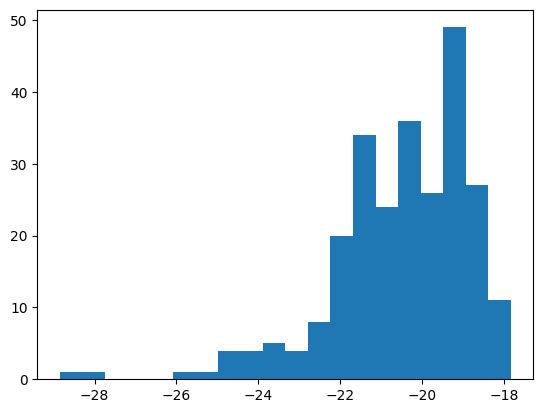

In [91]:
plt.hist(star_probs["JOKER_LN_LIKELIHOOD"],bins=20)

### Simulated Log-Likelihoods (No signal)

In [92]:
sim_samples = "samples/"+field+"/sim_samples_v7/"
sim_path = "toy_data/"+field+"_sim/sim_"
sim_files = glob(sim_samples+"*")

In [93]:
#calculate log LIKELIHOODs

col1 = Table.Column(name="LINEAR_LN_LIKELIHOOD",length=len(sim_files))
col2 = Table.Column(data=np.full((len(sim_files),256), np.nan), name="JOKER_LN_LIKELIHOOD")

sim_LIKELIHOODs = Table((col1,col2))

for file in sim_files:
    samples = tj.JokerSamples.read(file)

    foo_path = pathlib.Path(file)
    fID = foo_path.parts[-1].split(".")[0]
    ID = fID.split("_")[1]

    data_path = sim_path+ID+".fits"
    sim_data = Table.read(data_path)

    sim_data["VHELIO"].unit = u.km/u.s
    sim_data["VRELERR"].unit = u.km/u.s
    
    data = tj.RVData(t=sim_data["MJD"], rv = sim_data["VHELIO"], rv_err = sim_data["VRELERR"])

    sugar = samples.ln_unmarginalized_likelihood(data)
    frosting = np.append(sugar,np.full(256-len(sugar), np.nan))

    x,y,y_err,best_pars_linalg = lin_fit(data)
    
    cake = ln_likelihood(x,y,y_err,best_pars_linalg)

    (sim_LIKELIHOODs["LINEAR_LN_LIKELIHOOD"][int(ID)-1]) = cake
    (sim_LIKELIHOODs["JOKER_LN_LIKELIHOOD"][int(ID)-1]) = frosting

INFO: Filtering 1 NaN/Inf data points [thejoker]
INFO: Filtering 2 NaN/Inf data points [thejoker]
INFO: Filtering 1 NaN/Inf data points [thejoker]
INFO: Filtering 3 NaN/Inf data points [thejoker]
INFO: Filtering 15 NaN/Inf data points [thejoker]
INFO: Filtering 2 NaN/Inf data points [thejoker]
INFO: Filtering 12 NaN/Inf data points [thejoker]
INFO: Filtering 1 NaN/Inf data points [thejoker]
INFO: Filtering 10 NaN/Inf data points [thejoker]
INFO: Filtering 4 NaN/Inf data points [thejoker]
INFO: Filtering 3 NaN/Inf data points [thejoker]
INFO: Filtering 2 NaN/Inf data points [thejoker]
INFO: Filtering 11 NaN/Inf data points [thejoker]
INFO: Filtering 1 NaN/Inf data points [thejoker]
INFO: Filtering 1 NaN/Inf data points [thejoker]
INFO: Filtering 10 NaN/Inf data points [thejoker]
INFO: Filtering 13 NaN/Inf data points [thejoker]
INFO: Filtering 3 NaN/Inf data points [thejoker]
INFO: Filtering 2 NaN/Inf data points [thejoker]
INFO: Filtering 11 NaN/Inf data points [thejoker]
INFO: Filteri

(array([32.,  3.,  6.,  7., 10., 11., 17., 12., 10., 14., 12., 10., 16.,
        12., 17., 14., 11., 17., 12., 13.]),
 array([3.17370095e+00, 5.13590981e+02, 1.02400826e+03, 1.53442554e+03,
        2.04484282e+03, 2.55526010e+03, 3.06567738e+03, 3.57609466e+03,
        4.08651194e+03, 4.59692922e+03, 5.10734650e+03, 5.61776378e+03,
        6.12818106e+03, 6.63859834e+03, 7.14901562e+03, 7.65943290e+03,
        8.16985018e+03, 8.68026746e+03, 9.19068474e+03, 9.70110202e+03,
        1.02115193e+04]),
 <BarContainer object of 20 artists>)

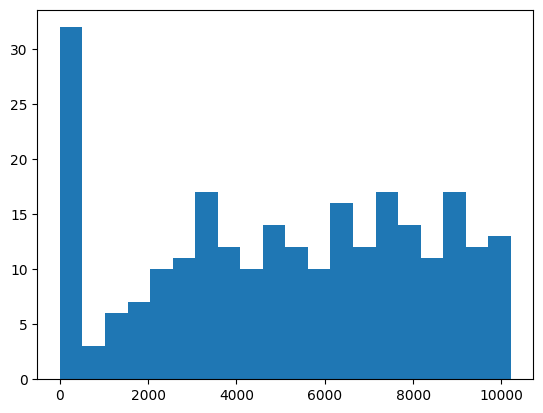

In [94]:
plt.hist(samples["P"],bins=20)

### Simulated Log-Likelihoods (with signal)

In [95]:
sim_samples_2 = "samples/"+field+"/batch_test/"
sim_path_2 = "toy_data/"+field+"_sim_rvs_5/%s/rv_sim_"
sim_files_2 = glob(sim_samples_2+"*/*")

In [96]:
blep = pathlib.Path(sim_files_2[6])
blep.parts[3]

'2M10122523-0122257'

In [97]:
(np.where(apo_vpm["APOGEE_ID"]==sID)[0][0]+1) * kruns

7000

In [98]:
#col3 = Table.Column(name="LINEAR_LN_LIKELIHOOD",length=len(sim_files_2))
#col4 = Table.Column(data=np.full((len(sim_files_2),256), np.nan), name="JOKER_LN_LIKELIHOOD")

col3 = Table.Column(name="LINEAR_LN_LIKELIHOOD",length=7000)
col4 = Table.Column(data=np.full((7000,256), np.nan), name="JOKER_LN_LIKELIHOOD")

sim_rv_LIKELIHOODs = Table((col3,col4))

for file in sim_files_2:
    samples = tj.JokerSamples.read(file)

    foo_path = pathlib.Path(file)
    fID = foo_path.parts[-1].split(".")[0]
    ID = fID.split("_")[1]

    blep = pathlib.Path(file)
    sID = blep.parts[3]

    data_path = (sim_path_2 %sID)+ID+".fits"
    sim_data = Table.read(data_path)

    #print(data_path)

    sim_data["VHELIO"].unit = u.km/u.s
    sim_data["VRELERR"].unit = u.km/u.s
    
    data = tj.RVData(t=sim_data["MJD"], rv = sim_data["VHELIO"], rv_err = sim_data["VRELERR"])

    sugar = samples.ln_unmarginalized_likelihood(data)
    frosting = np.append(sugar,np.full(256-len(sugar), np.nan))

    x,y,y_err,best_pars_linalg = lin_fit(data)
    
    cake = ln_likelihood(x,y,y_err,best_pars_linalg)

    ind = ((np.where(apo_vpm["APOGEE_ID"]==sID)[0][0]) * kruns )+ (int(ID)-1)
    #print(ind)

    (sim_rv_LIKELIHOODs["LINEAR_LN_LIKELIHOOD"][ind]) = cake
    (sim_rv_LIKELIHOODs["JOKER_LN_LIKELIHOOD"][ind]) = frosting

### False Positive estimation. 

Threshold for selecting "binaries":
- For each simulated system:
    - Compute ∆log-likelihood for all Joker samples (I'll abbreviate that as ∆LL)
    - Compute the mean ∆LL
- Now you have an array of mean ∆LL (one per simulated system)
    - Compute nanpercentile(mean simulated ∆LL, 95) to get a threshold value (or 99, or 90 depending on the contamination rate we want to take on)
- For each APOGEE system:
    - Compute ∆LL for all Joker samples
    - Compute the 5th percentile value
- Now you have an array of 5th percentile ∆LL values (one per APOGEE system)
- Your binary system mask will then be:
    - (5th percentile APOGEE ∆LL) > (threshold)

In [99]:
#Step 1: Array of all mean simulated ∆LL 
sim_delta_ll = sim_LIKELIHOODs["JOKER_LN_LIKELIHOOD"]-sim_LIKELIHOODs["LINEAR_LN_LIKELIHOOD"][:,None]
sim_mean_delta_ll = np.nanmean(sim_delta_ll,axis=1)
#Step 2: Compute percentile value
sim_percentile = np.nanpercentile(sim_mean_delta_ll,99)

In [100]:
#Step 3: Calculate ∆LL for all Joker samples
apo_delta_ll = apo_vpm["JOKER_LN_LIKELIHOOD"]-apo_vpm["LINEAR_LN_LIKELIHOOD"][:,None]
apo_percentile = np.nanpercentile(apo_delta_ll,5,axis=1)
threshold = apo_percentile>sim_percentile

KeyError: 'JOKER_LN_LIKELIHOOD'

In [ ]:
print(sum(threshold))
print(np.where(threshold)[0] + 1)

In [ ]:
can_mask = threshold & (apo_vpm["LOGG"]<3)
apo_can = apo_vpm[can_mask]
apo_vpm.add_column(threshold,name="BINARY_CANDIDATE")

### False Negative Estimation

In [ ]:
sim_rv_LIKELIHOODs_red = sim_rv_LIKELIHOODs[sim_rv_LIKELIHOODs["LINEAR_LN_LIKELIHOOD"]!=0.0]

In [ ]:
sim_rv_LIKELIHOODs_red

In [ ]:
#Step 3: Calculate ∆LL for all Joker samples
sim_signal_delta_ll = sim_rv_LIKELIHOODs_red["JOKER_LN_LIKELIHOOD"]-sim_rv_LIKELIHOODs_red["LINEAR_LN_LIKELIHOOD"][:,None]
sim_signal_percentile = np.nanpercentile(sim_signal_delta_ll,5,axis=1)
recovered = sim_signal_percentile>sim_percentile
completion = np.sum(recovered)/len(recovered)
print(completion)

In [ ]:
binary_fraction = len(apo_can_samples)/len(apo_vpmg)
print(binary_fraction/completion)

### Recovery Rate stuff, still under construction

In [ ]:
orbit_params = np.array((0,6))

for file in sim_files_2:
    samples = tj.JokerSamples.read(file)

    foo_path = pathlib.Path(file)
    fID = foo_path.parts[-1].split(".")[0]
    ID = int(fID.split("_")[1])
    dictionary = dictarray[ID-1]

    recov = recovered[ID]
    #print(recov)
    dictionary.update({"recovered": recov })
    

In [ ]:
orbit_params = Table(dictlist)

In [ ]:

recovered_params = orbit_params[orbit_params["recovered"]]
print(np.nansum(recovered_params['recovered']))
print(np.sum(recovered_params['period']< 1024))
print(np.sum(orbit_params['period']< 1024)/len(orbit_params))
recovered_params2 = recovered_params[recovered_params['period']<1024]

In [ ]:
print(len(recovered_params2)/np.sum(~orbit_params['recovered'].mask))

In [ ]:
recovered_params2

In [ ]:
#Make plots of all sim stars, highlight "positive" detections in green
#Increase number of simulated orbits....also do it in batches so it doesn't run for like 8 days
# Limit M2 to be <= m1
# Add third star for 8% of systems?
# Goal of 1 period per day

In [ ]:
op = orbit_params
thing = (op['m2']**3 *np.sin(op['inclination'])**3)/(op['m2']+op['m1'])**2 * (2*np.pi*c.G)/op['period'] * (1-op['eccentricity'])**(-3/2)
K = (thing**(1/3)).to(u.km/u.s)
orbit_params["K"]=K

In [ ]:
rp = recovered_params2
thing = (rp['m2']**3 *np.sin(rp['inclination'])**3)/(rp['m2']+rp['m1'])**2 * (2*np.pi*c.G)/rp['period'] * (1-rp['eccentricity'])**(-3/2)
K2 = (thing**(1/3)).to(u.km/u.s)
recovered_params2["K"]=K2

In [ ]:
plt.title("generated semi-amplitude (log km/s)")
n, bins, container= plt.hist(np.log10(orbit_params["K"]),bins=20, range =[-4,4])
n_recov, bins, container =plt.hist(np.log10(recovered_params2["K"]),bins=bins)

In [ ]:
plt.plot(bins[:-1],n_recov/n)

In [ ]:
plt.hist(np.log10(recovered_params['period']), bins=20)
plt.xlabel("Original orbital period - log(days)")

In [ ]:
plt.hist(recovered_params['m2'], bins=10)
plt.xlabel("Original companion mass - m2")

In [ ]:
plt.hist(orbit_params['m2'], bins=10)
plt.xlabel("Original companion mass - m2")

In [ ]:
plt.xlabel("Original orbital period - log(days)")
n, bins, thing = plt.hist(np.log10(orbit_params['period']), bins=20, label="Simulated periods")
plt.hist(np.log10(recovered_params2['period']), bins=bins, label="Recovered periods")
plt.legend()

In [ ]:
plt.scatter(np.log10(recovered_params['period']), recovered_params['eccentricity'])
plt.title("e vs P of recovered stars")

In [ ]:
orbit_params

Plot recovery fraction as a function of estimated period...do this in bins? We need original star periods....shit. Add a header to the fits file with the original period. 

In [ ]:
read_path = sim_files_2[110]
samples = tj.JokerSamples.read(read_path)

foo_path = pathlib.Path(sim_files_2[110])
fID = foo_path.parts[-1].split(".")[0]
ID = fID.split("_")[1]

data_path = sim_path_2+ID+".fits"
sim_data = Table.read(data_path)

sim_data["VHELIO"].unit = u.km/u.s
sim_data["VRELERR"].unit = u.km/u.s
    
data1 = tj.RVData(t=sim_data["MJD"], rv = sim_data["VHELIO"], rv_err = sim_data["VRELERR"])
    
plt.figure(figsize=(8,5))
    #_ = tj.plot_rv_curves(top_samples, data=data) #swap out with the one below if you want the top 10 Joker samples
_ = tj.plot_rv_curves(samples, data=data1)

In [ ]:
sim_files[117]

## Binary fraction estimation

In [76]:
min_p = 12*u.day 
max_p = 1400*u.day #twice our observing window

min_m2 = (13*u.jupiterMass).to(u.solMass)
max_m2 = 10*get_m_gal() #Not used, just here for posterity

max_K = get_K(get_m_gal(), max_m2, min_p, e=0) #Not used, just herefor posterity
min_K = get_K(get_m_gal(), min_m2, max_p, e=0) 

In [77]:
def estimate_binary_fraction(path):
    samples_files = glob(path+"/*")

    pass_fracs = np.empty(0)

    for file in samples_files:  #Get portion of samples that 'passes'
        samples = tj.JokerSamples.read(file)
        sID = pathlib.Path(file).parts[-1].split("_")[1]

        close_samples = (samples["P"]<max_p)& (np.abs(samples["K"])>min_K) & (samples["P"]>min_p) # & (masses<max_m2)& (masses>min_m2)
        frac = np.sum(close_samples)/len(samples)

        pass_fracs = np.append(pass_fracs, frac)
    #print(pass_fracs)

    def plotter():
        x = np.linspace(0,1,500)  #Let's see what the likelihood looks like as a function of f
        ll = np.array([binary_fraction_log_likelihood(i, pass_fracs) for i in x])
        plt.plot(x,np.exp(ll-np.max(ll)))

    def binary_fraction_log_likelihood(f, p_values):
        """Log-likelihood for binary fraction given per-star probabilities."""
        # avoid log(0)
        mix = np.clip( (1 - f) * (1 - p_values) + (f * p_values)  , 1e-12,1.0)
        return np.sum(np.log(mix))

    def neg_likelihood(f, p_values): #Wraper to invert the curve, because optimizers like minimizing, not maximizing.
        return -binary_fraction_log_likelihood(f, p_values)

    def objective(f):  #Yet another wrapper to make function easier for the optimier to handle
        return neg_likelihood(f,pass_fracs)

    plotter()

    result = sp.optimize.minimize(objective, x0=0.5,bounds=[(0,1)])
    return result

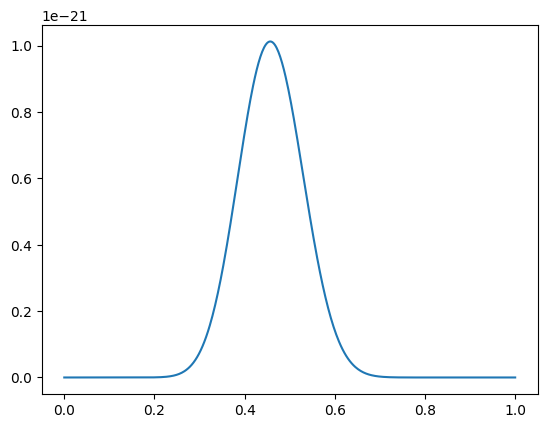

In [78]:
samples_files = glob("samples/SEXTANS/Sextans_P_2-1024_sk_30_sv_100-0.05_trend_2_rvall"+"/*")

pass_fracs = np.empty(0)

for file in samples_files:  #Get portion of samples that 'passes'
    samples = tj.JokerSamples.read(file)
    sID = pathlib.Path(file).parts[-1].split("_")[1]

    close_samples = (samples["P"]>min_p)& (samples["P"]<max_p)& (np.abs(samples["K"])>min_K)  #& (masses<max_m2)& (masses>min_m2)
    frac = np.sum(close_samples)/len(samples)

    pass_fracs = np.append(pass_fracs, frac)

def binary_fraction_log_likelihood(f, p_values):
    """Log-likelihood for binary fraction given per-star probabilities."""
    # avoid log(0)
    mix = np.clip( (1 - f) * (1 - p_values) + (f * p_values)  , 1e-12,1.0)
    return np.multiply.reduce(mix)

x = np.linspace(0,1,500)  #Let's see what the likelihood looks like as a function of f

ll = np.array([binary_fraction_log_likelihood(i, pass_fracs) for i in x])

plt.plot(x,ll)

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 48.517545720006375
        x: [ 4.948e-01]
      nit: 2
      jac: [ 4.974e-06]
     nfev: 10
     njev: 5
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>

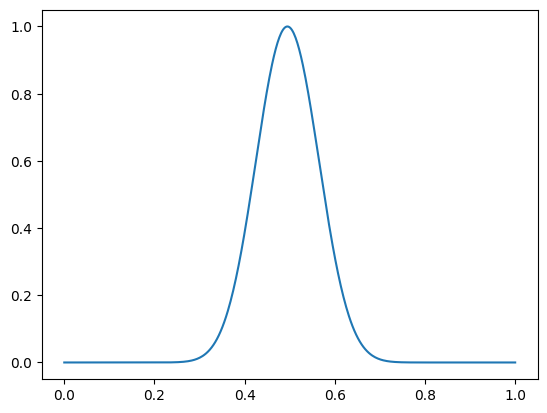

In [79]:
result = estimate_binary_fraction("samples/SEXTANS/Sextans_P_2-7110_sk_30_sv_100_trend_1_rvall")
result

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 48.47563101114906
        x: [ 4.789e-01]
      nit: 3
      jac: [ 1.421e-06]
     nfev: 12
     njev: 6
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>

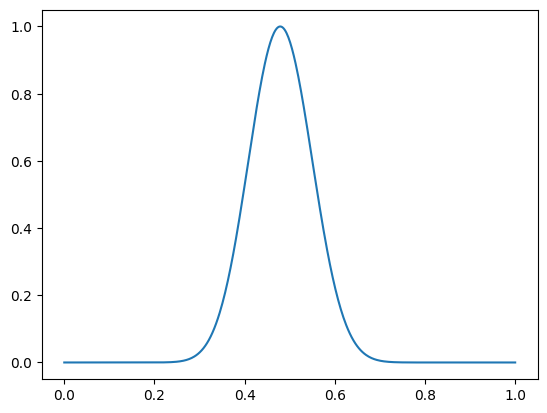

In [80]:
result0 = estimate_binary_fraction("samples/SEXTANS/Sextans_P_2-7110_sk_30_sv_100-0.05_trend_2_rvall")
result0

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 48.47563101114906
        x: [ 4.789e-01]
      nit: 3
      jac: [ 1.421e-06]
     nfev: 12
     njev: 6
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>

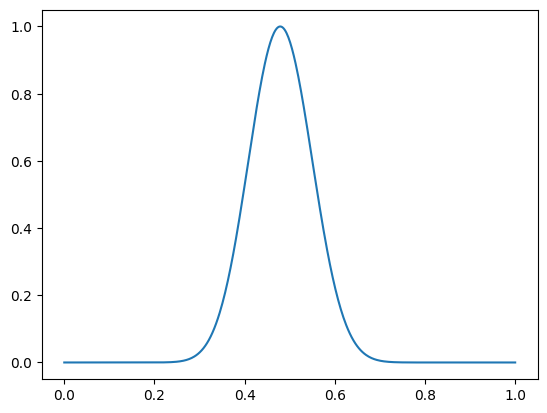

In [81]:
result1 = estimate_binary_fraction("samples/SEXTANS/Sextans_P_2-7110_sk_30_sv_100-0.05_trend_2_rvall")
result1

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 6.920432255519356
        x: [ 1.000e+00]
      nit: 1
      jac: [-5.955e+01]
     nfev: 4
     njev: 2
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>

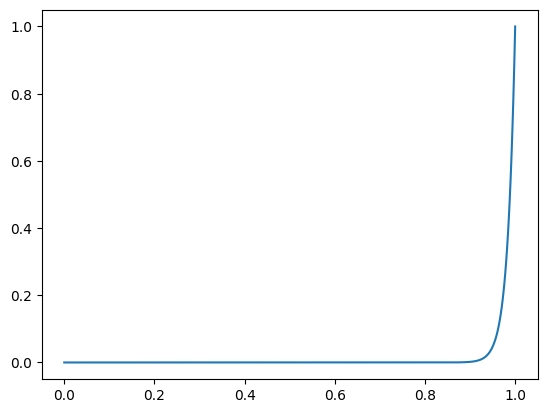

In [82]:
result2 = estimate_binary_fraction("samples/SEXTANS/Sextans_P_12-7110_sk_30_sv_100_trend_1_rvall")
result2

### Dynamic binary fraction, using star's surface gravity

(array([ 5., 30., 15.,  7.,  3.,  1.,  1.,  1.,  1.,  1.]),
 array([0.21390274, 0.7256391 , 1.2373755 , 1.74911189, 2.26084828,
        2.77258468, 3.28432083, 3.79605722, 4.30779362, 4.81953001,
        5.3312664 ]),
 <BarContainer object of 10 artists>)

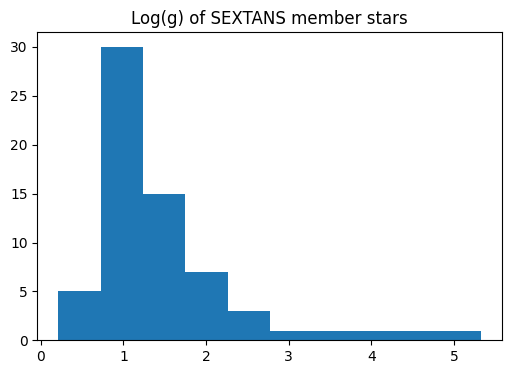

In [83]:
plt.figure(figsize=(6,4)) #Mean metalicity of the member stars.
plt.title("Log(g) of "+ field+" member stars")

plt.hist(apo_vpm["LOGG"])

(array([18., 20., 21.,  6.,  3.,  0.,  1.,  0.,  0.,  1.]),
 array([2.33825315e-02, 1.61243210e+01, 3.22252579e+01, 4.83261948e+01,
        6.44271317e+01, 8.05280685e+01, 9.66290131e+01, 1.12729950e+02,
        1.28830887e+02, 1.44931824e+02, 1.61032761e+02]),
 <BarContainer object of 10 artists>)

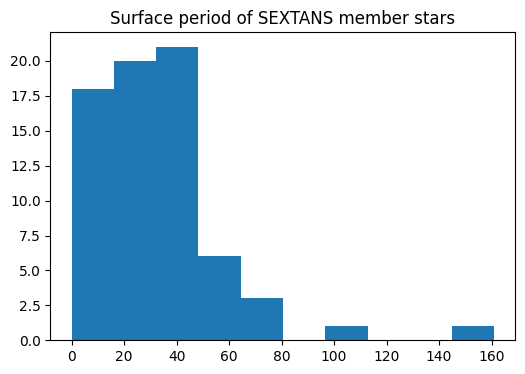

In [84]:
plt.figure(figsize=(6,4)) #Mean metalicity of the member stars.
plt.title("Surface period of "+ field+" member stars")

plt.hist(period_at_surface(get_m_gal(), apo_vpm["LOGG"]))

In [85]:
period_at_surface(get_m_gal(), np.median(apo_vpm["LOGG"]))

/Users/quentinlucas/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


<Quantity 27.15134015 d>

In [86]:
period_at_surface(get_m_gal(), np.mean(apo_vpm["LOGG"]))

<Quantity 17.5064107 d>

In [97]:
min_p = 27*u.day 

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 44.246546774050564
        x: [ 7.022e-01]
      nit: 5
      jac: [-1.421e-06]
     nfev: 14
     njev: 7
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>

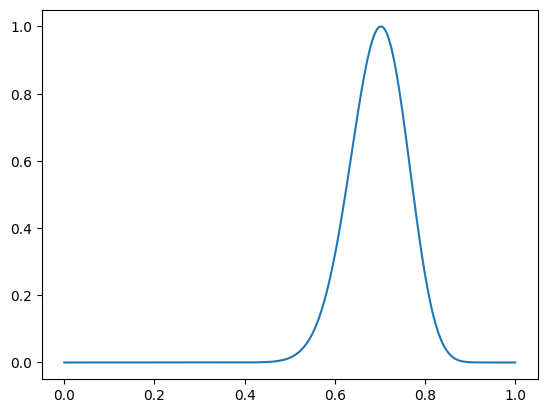

In [88]:
result3 = estimate_binary_fraction("samples/SEXTANS/Sextans_P_12-7110_sk_30_sv_100_trend_1_rvall")
result3

In [89]:
#min_p = 17.5*u.day 

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 45.92287629112713
        x: [ 3.479e-01]
      nit: 5
      jac: [ 7.105e-07]
     nfev: 14
     njev: 7
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>

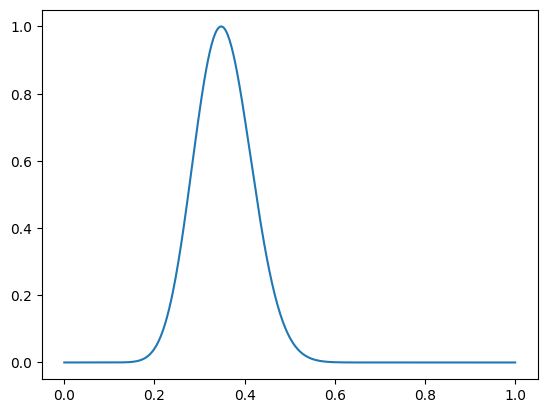

In [98]:
result4 = estimate_binary_fraction("samples/SEXTANS/Sextans_P_2-7110_sk_30_sv_100_trend_1_rvall")
result4

In [91]:
def estimate_binary_fraction_dynamic(path):
    samples_files = glob(path+"/*")

    pass_fracs = np.empty(0)

    for file in samples_files:  #Get portion of samples that 'passes'
        samples = tj.JokerSamples.read(file)
        sID = pathlib.Path(file).parts[-1].split("_")[0]
        p_min = period_at_surface(get_m_gal(), apo_vpm[apo_vpm["APOGEE_ID"]==sID]["LOGG"])

        close_samples = (samples["P"]>p_min)& (samples["P"]<max_p)& (np.abs(samples["K"])>min_K)  #& (masses<max_m2)& (masses>min_m2)
        frac = np.sum(close_samples)/len(samples)

        pass_fracs = np.append(pass_fracs, frac)
    #print(pass_fracs)

    def plotter():
        x = np.linspace(0,1,200)  #Let's see what the likelihood looks like as a function of f
        ll = np.array([binary_fraction_log_likelihood(i, pass_fracs) for i in x])
        plt.plot(x,np.exp(ll-np.max(ll)))

    def binary_fraction_log_likelihood(f, p_values):
        """Log-likelihood for binary fraction given per-star probabilities."""
        # avoid log(0)
        mix = np.clip((1 - f) * (1 - p_values) + f * p_values, 1e-12, 1.0)
        return np.sum(np.log(mix))

    def neg_likelihood(f, p_values): #Wraper to invert the curve, because optimizers like minimizing, not maximizing.
        return -binary_fraction_log_likelihood(f, p_values)

    def objective(f):  #Yet another wrapper to make function easier for the optimier to handle
        return neg_likelihood(f,pass_fracs)

    #plotter()

    result = sp.optimize.minimize(objective, x0=0.5)
    return result

Let's estimate spread, using the middle (result2) set of samples above:

In [92]:
samples_files = glob("samples/SEXTANS/Sextans_P_12-7110_sk_30_sv_100_trend_1_rvall/*")

In [93]:
pass_fracs = np.empty(0)

for file in samples_files:  #Get portion of samples that 'passes'
    samples = tj.JokerSamples.read(file)
    sID = pathlib.Path(file).parts[-1].split("_")[0]
    p_min = period_at_surface(get_m_gal(), apo_vpm[apo_vpm["APOGEE_ID"]==sID]["LOGG"])

    close_samples = (samples["P"]>p_min)& (samples["P"]<max_p)& (np.abs(samples["K"])>min_K)  #& (masses<max_m2)& (masses>min_m2)
    frac = np.sum(close_samples)/len(samples)

    pass_fracs = np.append(pass_fracs, frac)

def binary_fraction_log_likelihood(f, p_values):
    """Log-likelihood for binary fraction given per-star probabilities."""
        # avoid log(0)
    mix = np.clip((1 - f) * (1 - p_values) + f * p_values, 1e-12, 1.0)
    return np.sum(np.log(mix))

def neg_likelihood(f, p_values): #Wraper to invert the curve, because optimizers like minimizing, not maximizing.
    return -binary_fraction_log_likelihood(f, p_values)

In [94]:
resampled_f = np.empty(0)
for i in range(5000):
    inds = np.random.randint(0,len(pass_fracs)-1,len(pass_fracs))
    resampled_fracs = pass_fracs[inds]

    def resamp_obj(f):  #Yet another wrapper to make function easier for the optimzier to handle
        return neg_likelihood(f,resampled_fracs)

    result = sp.optimize.minimize(resamp_obj, x0=0.5)

    resampled_f = np.append(resampled_f, result.x[0])

Text(0.5, 0, 'Binary fraction')

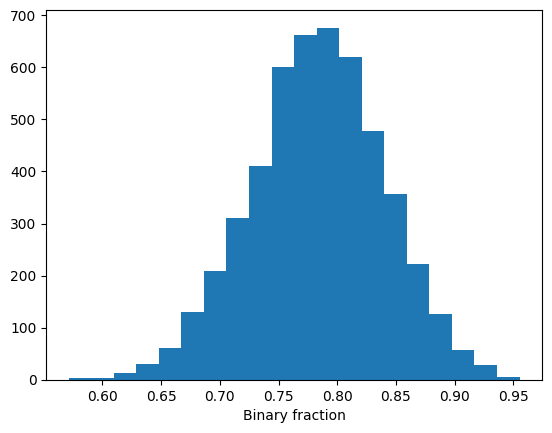

In [95]:
plt.hist(resampled_f, bins=20)
plt.xlabel("Binary fraction")

In [96]:
print(np.mean(resampled_f))
print(np.std(resampled_f))

0.7832798143657664
0.05640626150725041


## Calculate companion masses of candidate binaries

In [193]:
mass_col = Table.Column(data=np.full((len(apo_can),256), np.nan),length=len(apo_can))

In [194]:
col = Table.Column(data=np.full((len(apo_can),256), np.nan), name="MSINI")
apo_can.add_column(col)

#(apo_vpm["JOKER_LN_LIKELIHOOD"][apo_vpm["APOGEE_ID"]==sID]) = frosting

In [195]:
im_folder = "images/"+field+"/mass_period/"
if not os.path.exists(im_folder):
    os.makedirs(im_folder)

i = 0

for star in apo_can:
    sID = star['APOGEE_ID']
    read_path = path+sID+"_samples.hdf5"
    im_path = im_folder+sID +"_msini.png"
    samples = tj.JokerSamples.read(read_path)

    msini = mass2(samples["P"],samples["K"],samples["e"],mstar = m_gal)
    frosting = np.append(msini,np.full(256-len(msini), np.nan))
    (apo_can["MSINI"][apo_can["APOGEE_ID"]==sID]) = frosting

    #sugar = samples.ln_unmarginalized_likelihood(data) #Joker likelihoods
    #frosting = np.append(msini,np.full(256-len(msini), np.nan))

    #mass_col[i] = frosting

    #i+=1

    plt.figure(figsize=(8,5))
    plt.title(sID)
    plt.xlabel("Period (days)")
    plt.ylabel("Mass (solar)")

    plt.scatter(samples["P"],msini)
    plt.hlines(0.08, np.min(samples["P"]).value,np.max(samples["P"]).value, color="tab:red")
    
    plt.savefig(im_path,dpi=150)
    plt.close()

## Velocity Dispersion estimation

Hmm. Should we disinclude the stars that ASPCAP failed to fit? Start from there. Maybe do it both ways? Also make sure we don't consider the foreground stars, so use apo_vpmg instead. Also cut out the low-threshold detections. 

In [196]:
samples_mask = (np.sum(~np.isnan(apo_can["JOKER_LN_LIKELIHOOD"]),axis=1)>10) 
apo_can_samples = apo_can[samples_mask]

In [197]:
#not_can = (~threshold)& (apo_vpm["LOGG"]<3) 
not_can = ((~threshold)|(np.sum(~np.isnan(apo_vpm["JOKER_LN_LIKELIHOOD"]),axis=1)<10))& (apo_vpm["LOGG"]<3)
apo_not_can = apo_vpm[not_can.data | not_can.mask]

In [198]:
print("Stars in sample (log g limited): %i" %len(apo_vpmg))
print("Candidate stars (n samples limited): %i" %len(apo_can_samples))
print("Non-candidate stars: %i" %len(apo_not_can))

Stars in sample (log g limited): 66
Candidate stars (n samples limited): 18
Non-candidate stars: 48


In [199]:
binary_fraction = len(apo_can_samples)/len(apo_vpmg)
print(binary_fraction)

0.2727272727272727


(array([26., 24., 13.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([ 0.08730303,  0.57395297,  1.0606029 ,  1.54725289,  2.03390288,
         2.52055264,  3.00720263,  3.49385262,  3.98050261,  4.4671526 ,
         4.95380259,  5.44045258,  5.92710209,  6.41375208,  6.90040207,
         7.38705206,  7.87370205,  8.36035156,  8.84700203,  9.33365154,
         9.82030201, 10.30695152, 10.79360199, 11.2802515 , 11.76690197,
        12.25355148]),
 <BarContainer object of 25 artists>)

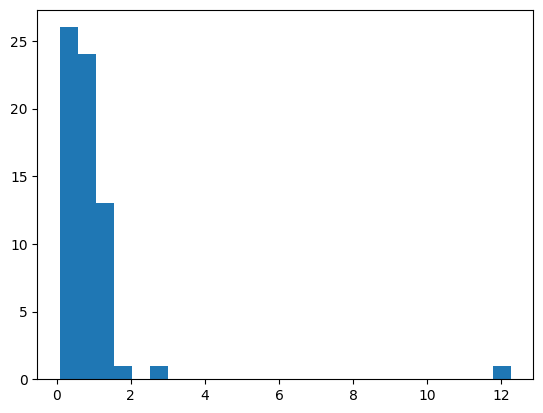

In [200]:
plt.hist(apo_vpmg["VERR"],bins=25)

In [201]:
print(np.std(apo_vpmg["VHELIO_AVG"]))
print(np.std(apo_not_can["VHELIO_AVG"]))
print(np.std(apo_can["VHELIO_AVG"]))

8.675596996464298
9.193215562392812
7.203290565187226


In [202]:
print(mad(apo_vpmg["VHELIO_AVG"]))
print(mad(apo_not_can["VHELIO_AVG"]))
print(mad(apo_can["VHELIO_AVG"]))

8.709484927355103
9.20437943010212
7.9048402174581405


In [75]:
print(np.sqrt(np.mean(apo_vpmg["VHELIO_AVG"]**2)) )
print(np.sqrt(np.mean(apo_not_can["VHELIO_AVG"]**2)) )
print(np.sqrt(np.mean(apo_can["VHELIO_AVG"]**2)) )


224.91724
224.03818
225.83842


In [76]:
print(np.mean(apo_vpmg["VHELIO_AVG"]))
print(np.mean(apo_not_can["VHELIO_AVG"]))
print(np.mean(apo_can["VHELIO_AVG"]))

224.74983723958334
223.8494873046875
225.72349964488637


(array([0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 3., 2., 1., 1., 2., 3.,
        0., 2., 1., 1., 1., 0., 1., 0.]),
 array([202.13746643, 203.65951538, 205.18156433, 206.70361328,
        208.22566223, 209.74771118, 211.26976013, 212.79180908,
        214.31385803, 215.83590698, 217.35795593, 218.88000488,
        220.40205383, 221.92408752, 223.44613647, 224.96818542,
        226.49023438, 228.01228333, 229.53433228, 231.05638123,
        232.57843018, 234.10047913, 235.62252808, 237.14457703,
        238.66662598, 240.18867493]),
 <BarContainer object of 25 artists>)

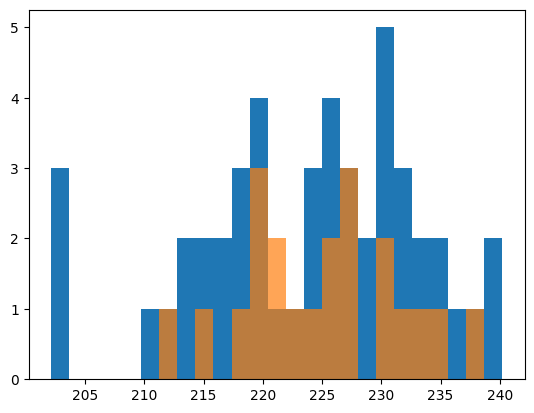

In [77]:
out = plt.hist(apo_not_can["VHELIO_AVG"],bins=25)
plt.hist(apo_can["VHELIO_AVG"],bins=out[1],alpha=0.7)

# Part 5: Post-Joker plots

## Summary Plots (of the entire galaxy)

To make: Eccentricity as a function of P....should this be for every star, or just the binaries? Maybe add the binaries in a different marker? That might be a good idea. See what that looks like. 

### Make E vs P plot for all samples

Look in Adrian's paper for inspiration on styling

Should include all returned samples?

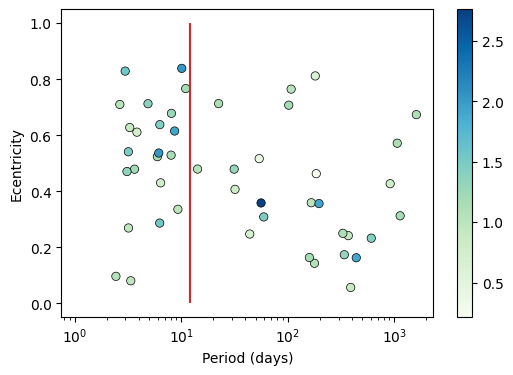

In [90]:
plt.figure(figsize=[6,4])
plt.scatter(apo_can["P_BAR"],apo_can["e_BAR"],c = apo_can["LOGG"],cmap = "GnBu",edgecolors='k',linewidth=0.5)

#plt.yscale('log')
plt.xscale('log')

plt.xlabel("Period (days)")
plt.ylabel("Ecentricity")
plt.vlines(12,0,1, color = "tab:red")
plt.colorbar()

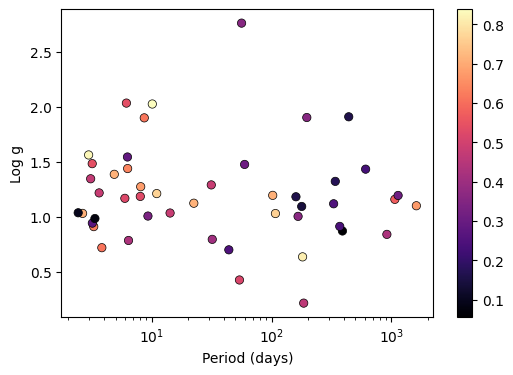

In [92]:
plt.figure(figsize=[6,4])
plt.scatter(apo_can["P_BAR"],apo_can["LOGG"],c = apo_can["e_BAR"],cmap = "magma",edgecolors='k',linewidth=0.5)

#plt.yscale('log')
plt.xscale('log')

plt.xlabel("Period (days)")
plt.ylabel("Log g")
plt.colorbar()

### Calculate & plot summary of masses

Ideas: Calculate median masses, standard deviation...how to plot these though? Against median period? Log g?

Text(0, 0.5, 'Avg companion mass (solar)')

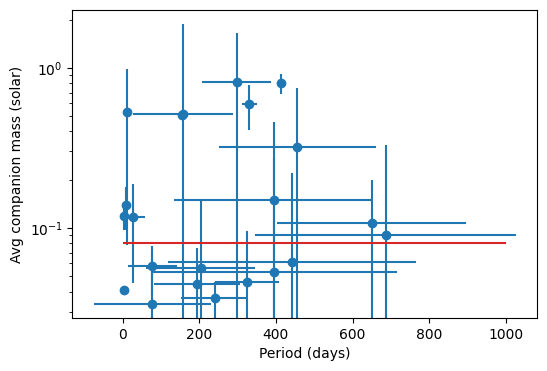

In [87]:
plt.figure(figsize=[6,4])

m_bar = np.empty(0,dtype=float)
m_std = np.empty(0,dtype=float)


for star in apo_can:
    m_avg = np.nanmedian(star["MSINI"])
    m_bar = np.append(m_bar, m_avg)

    m_var = np.nanstd(star["MSINI"])
    m_std = np.append(m_std, m_var)
    
plt.errorbar(apo_can["P_BAR"],m_bar, xerr=apo_can["P_STD"],yerr=m_std,fmt="o")
plt.hlines(0.08, 0,1000, color="tab:red")
plt.yscale('log')
#plt.xscale('log')

plt.xlabel("Period (days)")
plt.ylabel("Median companion mass (solar)")

Text(0, 0.5, 'Avg companion mass (solar)')

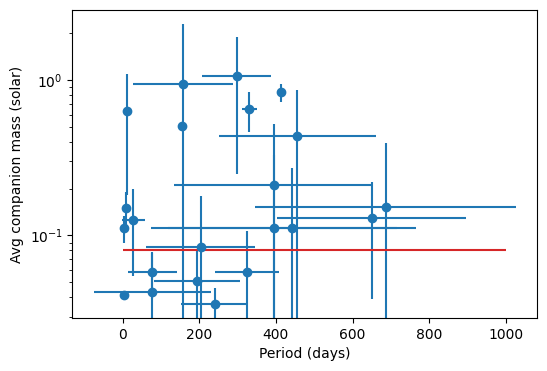

In [90]:
plt.figure(figsize=[6,4])

m_bar = np.empty(0,dtype=float)
m_std = np.empty(0,dtype=float)


for star in apo_can:
    m_avg = np.nanmean(star["MSINI"])
    m_bar = np.append(m_bar, m_avg)

    m_var = np.nanstd(star["MSINI"])
    m_std = np.append(m_std, m_var)
    
plt.errorbar(apo_can["P_BAR"],m_bar, xerr=apo_can["P_STD"],yerr=m_std,fmt="o")
plt.hlines(0.08, 0,1000, color="tab:red")
plt.yscale('log')
#plt.xscale('log')

plt.xlabel("Period (days)")
plt.ylabel("Avg companion mass (solar)")

## Bulk Plots (individual stars)

### RV curves

In [67]:
out_path = "images/"+field+"/rv_curves_fit_3/"
file_path = "samples/"+field+"/joker_samples_med/"
if not os.path.exists(out_path):
    os.makedirs(out_path)

In [69]:
for star in apo_vpm:  #Plot (and save) the Joker-fitted RV curves, with gallactic RV band 
    sID = star['APOGEE_ID']
    visits = all_visits[all_visits['APOGEE_ID']==sID]
    
    data = get_data(sID)
    #data = get_full_data(sID)
    data.rv_err = v_err_adj_2(data.rv_err)
    
    read_path = file_path+sID+"_samples.hdf5"
    im_path = out_path+sID +"_rv_curve.png"
    
    samples = tj.JokerSamples.read(read_path)

    sorted_lk = np.argsort(samples['ln_likelihood'])[::-1]
    top_samples = samples[sorted_lk[0:10]]
    
    plt.figure(figsize=(8,5))
    #_ = tj.plot_rv_curves(top_samples, data=data) #swap out with the one below if you want the top 10 Joker samples
    _ = tj.plot_rv_curves(samples, data=data)
    plt.title(sID)
    
    ax = plt.gca()
    ax.axhline(rv,color="tab:blue",lw=1)
    #ax.axhspan(rv-rv_scatter, rv + rv_scatter, facecolor="tab:blue", alpha=0.7)

    plt.scatter(data.t.mjd,data.rv,color='black');
    plt.errorbar(data.t.mjd,data.rv,yerr=data.rv_err,fmt="o",color='black');

    #good_visits = visits[visits['STARFLAG']==0] #This stuff colors good/bad visits differently
    #bad_visits = visits[visits['STARFLAG']>0]

    #plt.scatter(good_visits['JD'],good_visits['VHELIO'],color='black');
    #plt.errorbar(good_visits['JD'],good_visits['VHELIO'],yerr=good_visits['VRELERR'],fmt="o",color='black');

    #plt.scatter(bad_visits['JD'],bad_visits['VHELIO'],color='gray');
    #plt.errorbar(bad_visits['JD'],bad_visits['VHELIO'],yerr=bad_visits['VRELERR'],fmt="o",color='gray');
        
    plt.savefig(im_path,dpi=150)
    plt.close()

In [ ]:
fig, (ax1,ax2) = plt.subplots(2, 2)

fig.set_size_inches([12,4])
fig.suptitle("APOGEE visits of " +field+" field stars")

ax1.set_title("Number of Visits") #Get number of visits. I want to refine this using nan visits and RV reject
ax1.hist(apo_gal["NVISITS"],bins=25,color='dimgray');

ax2.set_title("log(g)") #See what kind of stars we have. Some of them appear to be dwarfs.
ax2.hist(apo_gal["LOGG"],bins=25,color='dimgray');

plt.savefig(im_folder + "/sextans_field_visits.png",dpi=150,bbox_inches='tight') 

### Period vs Ecentricity (& period histogram)

In [ ]:
out_path = "images/"+field+"/p_vs_e/"
if not os.path.exists(out_path):
    os.makedirs(out_path)

out_path2 = "images/"+field+"/p_hist/"
if not os.path.exists(out_path2):
    os.makedirs(out_path2)

In [ ]:
for star in apo_vpm:  
    sID = star['APOGEE_ID']
    data = get_data(sID)
    n_data = len(data)

    nu_max = star["NU_MAX"] *u.Hz
    P = (1/nu_max).to(u.day).value
    T = star["P_SURFACE"]
    ###
    
    read_path = path+sID+"_samples.hdf5"
    hist_path = out_path+sID+"_histogram.png"
    Pe_path = out_path2+sID+"_pe_scatter.png"
    
    samples = tj.JokerSamples.read(read_path)
    n_samples = len(samples)
    
    textstr = '\n'.join((
        r'Visits: %d' % (n_data, ),
        r'Samples: %d' % (n_samples, )))
    
    plt.figure(figsize=(8,5))
    plt.hist(samples["P"],bins=20,color="black")
    
    plt.xlabel("Period (days)")
    plt.ylabel("# of returned samples")
    plt.title("Period Histogram of Joker Samples")
    
    ax = plt.gca()
    leg = ax.legend(labels=[textstr],handlelength=0, handletextpad=0, fancybox=True)
    for item in leg.legend_handles:
            item.set_visible(False)
    
    plt.savefig(hist_path,dpi=200)
    plt.close()
    ###
    
    plt.figure(figsize=(8,5))
    plt.scatter(samples["P"],samples["e"], color="black")
    plt.vlines(T,0,1,colors='tab:red',label="Stellar Surface")
    plt.vlines(P,0,1,colors='tab:green',label="Max Oscillation Mode")
    
    plt.xlabel("Period (days)")
    plt.ylabel("Eccentricity")
    plt.title("Eccentricity vs Period")
    
    ax = plt.gca()
    leg = ax.legend(labels=[textstr],handlelength=0, handletextpad=0, fancybox=True,loc='upper left')
    for item in leg.legend_handles:
            item.set_visible(False)

    plt.legend()
    ax.add_artist(leg)
    
    plt.savefig(Pe_path,dpi=200)
    plt.close()

### Log Probatility histograms

In [134]:
def log_prob_plotter(real_samples_folder,out_folder,reject_flag=False): #For real stars only
    
    #sim_likelihoods = calc_sim_likelihoods(sim_data_folder, sim_samples_folder)
    likelihoods = calc_real_likelihoods(real_samples_folder, reject_flag)

    #out_path = "images/"+field+"/likelihood_hist_"+ "_".join(real_samples_folder.split("_")[-3:])+"/" #fancy out-path thing
    out_path = "images/"+field+"/"+out_folder
    if not os.path.exists(out_path):
        os.makedirs(out_path)

    for star in likelihoods:
        sID = star["APOGEE_ID"]
        plt.figure(figsize=(8,5))
        im_path = out_path+"/"+sID +"_likelihoods.png"
    
        linear_lk = star["LINEAR_LN_LIKELIHOOD"]
        joker_lk = star["JOKER_LN_LIKELIHOOD"]

        plt.title("Log Likelihoods for "+sID)
        out = plt.hist(joker_lk,bins=25,color='tab:blue',label="Joker ln likelihoods")
        plt.vlines(linear_lk,0,np.max(out[0]),color='tab:red',label="Linear ln likelihood")

        plt.legend()
        plt.savefig(im_path,dpi=150)
        plt.close()

In [138]:
log_prob_plotter('samples_err_fit_5','likelihood_hist_test', False)

### Phase-Folded plots (takes a long time to run)

In [ ]:
for star in apo_vpm:  #Plot (and save) the Joker-fitted RV curves, phase-folded
    sID = star['APOGEE_ID']
    
    data = get_data(sID)
    
    read_path = path+sID+"_samples.hdf5"
    im_folder = "images/"+field+"/phase_folded/"+sID #+"_models.pdf"
    
    if not os.path.exists(im_folder):
        os.makedirs(im_folder)
    
    samples = tj.JokerSamples.read(read_path)

    vex = Table([samples.ln_unmarginalized_likelihood(data)], names=['likelihood'])
    vex = vex.group_by("likelihood")
    vex.add_column(np.flip(np.arange(len(samples))),name='index')
    
    for j in range(len(samples)):
        sample = samples[j]

        lnlk = sample.ln_unmarginalized_likelihood(data)[0]
        k = vex[vex['likelihood']==lnlk]['index']
        
        #plt.figure(figsize=(8,5))
        _ = tj.plot_phase_fold(sample, data=data)
        plt.title(sID+ " (phase folded)")
    
        P = sample['P'].value[0]
        e = sample['e'].value[0]
        K = sample['K'].value[0]
        v0 = sample['v0'].value[0]
        
        #print(e)
        
        textstr = '\n'.join((
            r'$P=%.2f$ days' % (P, ),
            r'$e=%.3f$' % (e, ),
            r'$K=%.3f$' % (K, ),
            r'$v_0=%.3f$' % (v0, )))
        
        ax = plt.gca()
        leg = ax.legend(labels=[textstr],handlelength=0, handletextpad=0, fancybox=True)
        for item in leg.legend_handles:
            item.set_visible(False)
        
        index = str(k.value[0])
        im_path =  im_folder +"/" + "Phase_" +index+ ".png"
        #print(im_path)
        
        plt.savefig(im_path,dpi=200)
        del(ax)
        plt.close()
    
    

# Website building things

Too much to write by hand, lots of stars. 

## Individual Star Pages

### Sub-functions for berevity

In [95]:
def mk_header(field_name, star):
    with open("web_templates/star_header.txt","r") as f:
        head_tmp = f.read()
        
    sID = star['APOGEE_ID']

    head_str = head_tmp % field_name
    return head_str

In [96]:
def mk_info(field_name, star): #Makes a summary info list
    with open("web_templates/info_box.txt","r") as f:
        info_tmp = f.read()
    
    sID = star['APOGEE_ID']
    k = np.where(apo_vpm["APOGEE_ID"]==sID)[0][0]+1
    gaia_dat = gaia_sub[gaia_sub["source_id"]==star["GAIAEDR3_SOURCE_ID"]]

    data = get_data(sID)
    read_path = path+sID+"_samples.hdf5"
    samples = tj.JokerSamples.read(read_path)

    n_visits = len(data)
    snr = star["SNR"]
    h = star["H"]
    g_m = star["GAIAEDR3_PHOT_G_MEAN_MAG"]

    ruwe = gaia_dat["ruwe"]
    gaia_n = gaia_dat["astrometric_excess_noise"]
    gaia_n_sig = gaia_dat["astrometric_excess_noise_sig"]
    gof = gaia_dat["astrometric_gof_al"]

    t = star["TEFF"]
    g = star["LOGG"]
    fe = star["M_H"]

    rv_t = star["RV_TEFF"]
    rv_g = star["RV_LOGG"]
    rv_fe = star["RV_FEH"]

    n_samples = len(samples)
    unimodal = tj.is_P_unimodal(samples,data)
    P_avg = np.mean(samples["P"]).value
    e_avg = np.mean(samples["e"]).value
    K_avg = np.mean(np.abs(samples["K"])).value
    min_del_lk = min(star["JOKER_LN_LIKELIHOOD"]-star["LINEAR_LN_LIKELIHOOD"])

    nu_max = star["NU_MAX"]
    delta_nu = star["DELTA_NU"]
    p_surface = star["P_SURFACE"]

    params = (k, sID,
              field_name, sID, sID,
              n_visits, snr, h, g_m,
              ruwe, gaia_n, gaia_n_sig, gof,
              t, g, fe,
              rv_t, rv_g, rv_fe,
              n_samples, unimodal, P_avg, e_avg, K_avg, min_del_lk,
              nu_max, delta_nu, p_surface)

    info_str = info_tmp %params
    return info_str

In [97]:
def mk_binary_info(field_name, star):
    with open("web_templates/binary_info.txt","r") as f:
        binary_tmp = f.read()

    sID = star['APOGEE_ID']
    params = (sID, sID)

    binary_str = binary_tmp %params
    return binary_str

In [98]:
def mk_gallery(field_name, star):
    with open("web_templates/star_gallery.txt","r") as f:
        gallery_tmp = f.read()

    sID = star['APOGEE_ID']
    sreps = np.repeat(sID, 16)

    gallery_str = gallery_tmp % tuple(sreps) #Change the number of repeats if you change the page layout
    return gallery_str

In [99]:
def mk_visit_table(field_name, star):
    with open("web_templates/star_table_head.txt","r") as f:
        head_tmp = f.read()
    with open("web_templates/star_table_row.txt","r") as f:
        row_tmp = f.read()
    foot_str = '\n\t\t</table>\n'

    sID = star['APOGEE_ID']
    visits = all_visits[all_visits['APOGEE_ID']==sID]
    visits.sort("MJD")

    body_str = ''

    for visit in visits:

        if(visit["SNR"]<5):
            params = (visit["MJD"], "<b>"+str(visit["SNR"])+"</b>", visit["VHELIO"],visit["VRELERR"], 
                    visit["RV_TEFF"], visit["RV_LOGG"], visit["RV_FEH"],
                    visit["STARFLAGS"], visit["RV_FLAG"])
        else:
            params = (visit["MJD"], visit["SNR"], visit["VHELIO"],visit["VRELERR"], 
                       visit["RV_TEFF"], visit["RV_LOGG"], visit["RV_FEH"],
                       visit["STARFLAGS"], visit["RV_FLAG"])

        row_str = row_tmp % params
        body_str = body_str + row_str

    table_str = head_tmp + body_str + foot_str

    return table_str
#don't forget to add closing table tag

In [100]:
def mk_phase_gal(field_name, star):
    sID = star['APOGEE_ID']
    data = get_data(sID)
    read_path = path+sID+"_samples.hdf5"
    samples = tj.JokerSamples.read(read_path)
    
    phase_str = "\n<br>\n<hr>\n"
    
    for i in range(len(samples)):
        ind = str(i)
        phase_str = str(phase_str+'\t\t<img src="/images/sextans/phase_folded/'+
                        sID+'/Phase_'+ind+'.png" alt="Phase 0" id="three_image">\n')

    return phase_str

In [101]:
def mk_footer(field_name = "foo",star = "foo"):
    with open("web_templates/footer.txt","r") as f:
        foot_tmp = f.read()

    return foot_tmp

### Actual function calls

In [90]:
for star in apo_vpm:
    sID = star['APOGEE_ID']
    
    head_str = mk_header(field.lower(), star)
    info_str = mk_info(field.lower(), star)
    table_str = mk_visit_table(field.lower(), star)
    gallery_str = mk_gallery(field.lower(), star)
    phase_str = mk_phase_gal(field.lower(), star)
    foot_str = mk_footer()

    if(star["BINARY_CANDIDATE"]):
        binary_str = mk_binary_info(field.lower(), star)
    else:
        binary_str = ""

    out_path = "html/"+field+"/%s.html" %sID
    out = open(out_path, 'w')

    text = str(head_str+ info_str+ binary_str+ table_str+ gallery_str+ phase_str+ foot_str) #Add in stuff for phase folding
    
    out.write(text)

/var/folders/b5/gm7vz31d7cz5k6m1r9bknccr0000gp/T/ipykernel_99887/3076544127.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  info_str = info_tmp %params
/var/folders/b5/gm7vz31d7cz5k6m1r9bknccr0000gp/T/ipykernel_99887/2109466406.py:25: UserWarning: Warning: converting a masked element to nan.
  row_str = row_tmp % params
/var/folders/b5/gm7vz31d7cz5k6m1r9bknccr0000gp/T/ipykernel_99887/3076544127.py:51: UserWarning: Warning: converting a masked element to nan.
  info_str = info_tmp %params


## Summary Table for a galaxy

re-write this part to open the html file, and append stuff to it?

In [114]:
def mk_gal_row(field_name, samples_folder, thresholds, star):
    with open("web_templates/gal_table_row.txt","r") as f:
        row_tmp = f.read()

    sID = star['APOGEE_ID']
    k = np.where(apo_vpm["APOGEE_ID"]==sID)[0][0]+1
    data = get_data(sID)
    read_path = "samples/"+field+"/"+samples_folder+sID+"_samples.hdf5"
    samples = tj.JokerSamples.read(read_path)

    if(thresholds[k-1]):
        tag = " id='binary'"
    else:
        tag = ""

    foo = sID.split("-")
    sID_split = foo[0]+"<br>-"+foo[1]

    t = star["TEFF"]
    g = star["LOGG"]
    fe = star["M_H"]
    h = star["H"]
    g_m = star["GAIAEDR3_PHOT_G_MEAN_MAG"]

    n_samples = len(samples)
    unimodal = tj.is_P_unimodal(samples,data)
    P_avg = np.mean(samples["P"]).value
    e_avg = np.mean(samples["e"]).value

    gaia_dat = gaia_sub[gaia_sub["source_id"]==star["GAIAEDR3_SOURCE_ID"]]
    gaia_n = gaia_dat["astrometric_excess_noise"]

    params = (tag, k,
              field_name, sID, sID_split,
              t, g, fe, h, g_m,
              field_name, sID, field_name, sID, sID,
              n_samples, unimodal, P_avg, e_avg, gaia_n,
              field_name, sID, field_name, sID, sID)

    print(k)

    row_str = row_tmp % params
    return row_str

In [117]:
page_path = "html/galaxy/%s.html" %field.lower()

with open(page_path) as f:
    lines = f.readlines()

lines = np.array(lines,dtype='U1000')

start = np.where(lines=="<!--start-->\n")[0][0]+1
stop = np.where(lines=="<!--stop-->\n")[0][0]

lines = np.delete(lines, range(start,stop-1))

table_str = np.empty(0,dtype='U1500')

for star in apo_vpm:
    row_str = mk_gal_row(field.lower(),'joker_samples_med/',threshold0, star)
    table_str = np.append(table_str,row_str)

table_str = np.append(table_str,['\n\n'])

out_page = np.insert(lines, start, table_str)

with np.printoptions(threshold=np.inf):
    print(out_page)

with open(page_path, 'w') as out:
    out.writelines(out_page)
    #print(foo)

1
2
3
4


/var/folders/b5/gm7vz31d7cz5k6m1r9bknccr0000gp/T/ipykernel_21041/7080317.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  row_str = row_tmp % params


5
6
7
8


/var/folders/b5/gm7vz31d7cz5k6m1r9bknccr0000gp/T/ipykernel_21041/7080317.py:42: UserWarning: Warning: converting a masked element to nan.
  row_str = row_tmp % params


9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
['<!DOCTYPE HTML>\n' '<html>\n' '\n' '<head>\n'
 '  <meta charset="UTF-8">\n'
 '  <title>Quentin Lucas - Sextans Galaxy</title>\n'
 '  <link rel="stylesheet" href="/css/research.css"  type="text/css">\n'
 '  <link rel="stylesheet" href="/css/global.css" type="text/css">\n'
 '  <link href="https://fonts.googleapis.com/css?family=Slabo+27px" rel="stylesheet">\n'
 '</head>\n' '\n' '<body>\n' '\n' '\t<div id="header">\n' '\t\n' '\n'
 '\t\t<img width="300" style="margin:0px auto;display:inline" src="/images/logo.png" alt="Quentin Lucas, Astrophysics" title="Art by Siena Buchanan"/>\n'
 '\n' '\n' '\t<div id="info_box">\n' '\t\n' '\t\tDepartment of Physics\n'
 '\t\t<br>\n' '\t\tMontana State University\n' '\t\t<br>\n'
 '\t\tquentinlucas@msu.montana.edu\n' '\t\n' '\t</div>\n' '\t\n'
 '\t<ul id="nav_bar">\n' '\t\

In [120]:
r = 50
((4/3)*np.pi * r**3)/((4/3)*np.pi * (r*.35)**3)

23.323615160349853

In [121]:
r = 150
((4/3)*np.pi * r**3)/((4/3)*np.pi * (r*.35)**3)

23.323615160349856

In [124]:
(.04)**(1/3)

0.3419951893353394

## Prior Comparison Table

- RV curves with no prior
  

apo_delta_ll = apo_vpm["JOKER_LN_LIKELIHOOD"]-apo_vpm["LINEAR_LN_LIKELIHOOD"][:,None]

apo_percentile = np.nanpercentile(apo_delta_ll,5,axis=1)

In [132]:
def mk_comp_row(field_name, star):
    with open("web_templates/comparison_row_rv.txt","r") as f:
        row_tmp = f.read()

    sID = star['APOGEE_ID']
    k = np.where(apo_vpm["APOGEE_ID"]==sID)[0][0]+1
    data = get_data(sID)
    
    read_paths = np.array(['samples/SEXTANS/joker_samples_med/','samples/SEXTANS/samples_rv_reject_wtrend/',
                        'samples/SEXTANS/samples_rv_reject_xtrend_smsigv/','samples/SEXTANS/samples_rv_reject_xtrend_smsigv_longp/'])
    flag = ['','','','','']
    if(apo_percentile0[k-1] > sim_percentile0):
        flag[0]= " id='binary'"
    if(apo_percentile1[k-1] > sim_percentile1):
        flag[1]= " id='binary'"
    if(apo_percentile2[k-1] > sim_percentile2):
        flag[2]= " id='binary'"
    if(apo_percentile3[k-1] > sim_percentile3):
        flag[3]= " id='binary'"
    if(apo_percentile4[k-1] > sim_percentile4):
        flag[4]= " id='binary'"
    
    #i = 0
    #for file in read_paths:
        #print(sID)
        #if (file==''):
         #   continue
            
        #x,y,y_err,best_pars_linalg = lin_fit(data)
        #samples = tj.JokerSamples.read(str(file)+str(sID)+"_samples.hdf5")

        #cake = ln_likelihood(x,y,y_err,best_pars_linalg)
        #sugar = samples.ln_unmarginalized_likelihood(data) #Joker likelihoods
        #frosting = np.append(sugar,np.full(256-len(sugar), np.nan))

        #delta_ll = cake-frosting#[:,None]
        #percentile = np.nanpercentile(delta_ll,5)
        #threshold = percentile>sim_percentiles[i]
        #print(percentile)

        #if threshold:
        #    flag[i]= " id='binary'"
        #i+=1
        
    
    params = (flag[0],k,
              flag[1],field_name, sID, field_name, sID, sID,
              flag[2],field_name, sID, field_name, sID, sID,
              flag[3],field_name, sID, field_name, sID, sID,
              flag[4],field_name, sID, field_name, sID, sID,)

    row_str = row_tmp % params
    return row_str

In [133]:
table_str = np.empty(0,dtype='U1000')

for star in apo_vpm:
    row_str = mk_comp_row(field.lower(), star)
    table_str = np.append(table_str,row_str)

table_str = np.append(table_str,['\n\n'])

with open('rv_comp_table.txt', 'w') as out:
    out.writelines(table_str)

In [ ]:
likelihoods2 = calc_real_likelihoods('N_samples_xtrend_rvrjt',reject_flag=True)

In [110]:

star_probs = likelihoods2[26]
star_probs

In [ ]:
plt.hist(star_probs[2],bins=20)

In [106]:
np.where(lines=="<!--start-->\n")[0][0]

62

## Spectra plotter

In [74]:
hdu2 = fits.open("../APOGEE-research/star_spectra/asVisit-dr17-10391-58922-118.fits")
hdu2.info()

Filename: ../APOGEE-research/star_spectra/asVisit-dr17-10391-58922-118.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      63   ()      
  1                1 ImageHDU        10   (4096, 3)   float32   
  2                1 ImageHDU        10   (4096, 3)   float32   
  3                1 ImageHDU        10   (4096, 3)   int16   
  4                1 ImageHDU        10   (4096, 3)   float64   
  5                1 ImageHDU        10   (4096, 3)   float32   
  6                1 ImageHDU        10   (4096, 3)   float32   
  7                1 ImageHDU        10   (4096, 3)   float32   
  8                1 ImageHDU        10   (4096, 3)   float32   
  9                1 ImageHDU        15   (14, 3)   float64   
 10                1 ImageHDU        31   (26, 3)   float64   
 11                1 BinTableHDU    171   1R x 77C   [18A, 18A, 33A, I, I, 12A, J, 6A, 8A, 7A, 9A, 17A, I, D, D, D, D, E, E, E, E, E, E, E, E, 8A, E, E, E, E, E, E, E,

In [75]:
foo2 = hdu2[1].data
lam2 = hdu2[4].data
msk2 = hdu2[3].data

In [82]:
masked_spec = foo2[1]*(1-( (msk2[1]&(2**12))!=0) )
masked_spec[masked_spec==0]*=np.nan


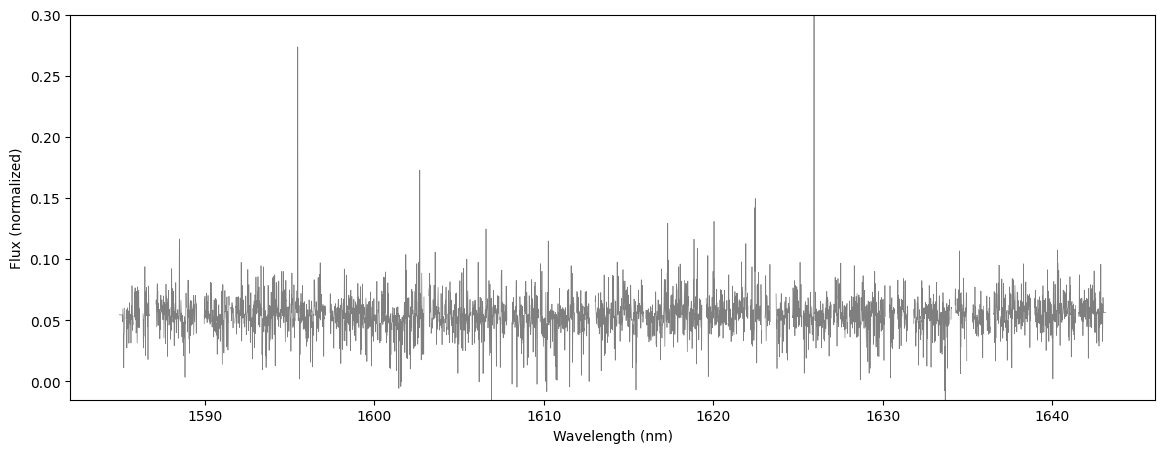

In [98]:
plt.figure(figsize=[14,5])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Flux (normalized)")

#plt.plot(lam2[0],foo2[0], c="tab:blue")
#plt.plot(lam2[1],foo2[1], c="tab:blue")
#plt.plot(lam2[2],foo2[2], c="tab:blue")


#plt.plot(lam[0],foo[0]*(1-( (msk[0]&(2**12))!=0) ), c="tab:orange",linewidth = 0.5) #118
plt.plot(lam2[1]/10,masked_spec/max(masked_spec), c="tab:gray",linewidth = 0.5)
#plt.plot(lam[2],foo[2]*(1-( (msk[2]&(2**12))!=0) ), c="tab:orange",linewidth = 0.5)

#plt.plot(lam[0],foo[0]*(1-( (msk[0]&(2**12))!=0) ), c="tab:orange",linewidth = 0.5) #118, different date
#plt.plot(lam3[1],foo3[1]*(1-( (msk3[1]&(2**12))!=0) ), c="tab:green",linewidth = 0.5)
#plt.plot(lam[2],foo[2]*(1-( (msk[2]&(2**12))!=0) ), c="tab:orange",linewidth = 0.5)

#plt.plot(lam2[0],foo2[0]*(1-( (msk2[0]&(2**12))!=0) ), c="tab:blue",alpha=0.5,linewidth = 0.5) #112
#plt.plot(lam2[1],foo2[1]*(1-( (msk2[1]&(2**12))!=0) ), c="tab:blue",alpha=0.5,linewidth = 0.5)
#plt.plot(lam2[2],foo2[2]*(1-( (msk2[2]&(2**12))!=0) ), c="tab:blue",alpha=0.5,linewidth = 0.5)

#plt.xlim(15950,15960)

plt.ylim(-0.015,0.3)
plt.savefig(im_folder + "/example_spectrum.png",dpi=150,bbox_inches='tight')

In [ ]:
print(len(visit_pile)) #Nominal number of visits

print(np.sum(visit_pile["VHELIO"].mask)) #Get number of masked visits

not_masked_visits = visit_pile[np.invert(visit_pile["VHELIO"].mask)]
print(len(not_masked_visits))
vreject_mask = (not_masked_visits["STARFLAG"] &(2**19)==0) ##Number of RV failure visits
print(np.sum(vreject_mask))